In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

In [3]:
blind = False
#fname_blind = '../output/some-sims-dv-cosmogrid/des-y3-2pt-blind-metacal-simcov.txt'

sim1 = utils.read_cosmosis_mcmc_des_chain('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim1.txt', to_mcsamples=True, blind=blind)
sim2 = utils.read_cosmosis_mcmc_des_chain('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim2.txt', to_mcsamples=True, blind=blind)
sim3 = utils.read_cosmosis_mcmc_des_chain('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim3.txt', to_mcsamples=True, blind=blind)

all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)
map3_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-map3-all.txt', to_mcsamples=True, blind=blind)
twpt_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-500simcov-17sep24.txt', to_mcsamples=True, blind=blind)
auto_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-auto.txt', to_mcsamples=True, blind=blind)
auto_334_344_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-auto-334-344.txt', to_mcsamples=True, blind=blind)

all_sims_wCDM = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-all-wCDM.txt', to_mcsamples=True, blind=blind)
twopoint_wCDM = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-500simcov-wCDM-17sep24.txt', to_mcsamples=True, blind=blind)
map3_wCDM = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-map3-all-wCDM.txt', to_mcsamples=True, blind=blind)

desy3_dm = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)
desy3_baryon = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-baryon-run/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 600x600 with 0 Axes>

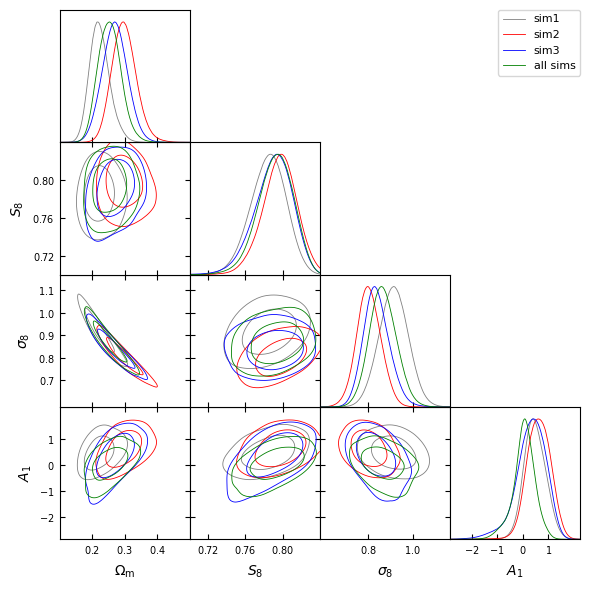

In [5]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([sim1, sim2, sim3, all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['sim1', 'sim2',  'sim3', 'all sims'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'blue', 'green'])
plt.show()

<Figure size 600x600 with 0 Axes>

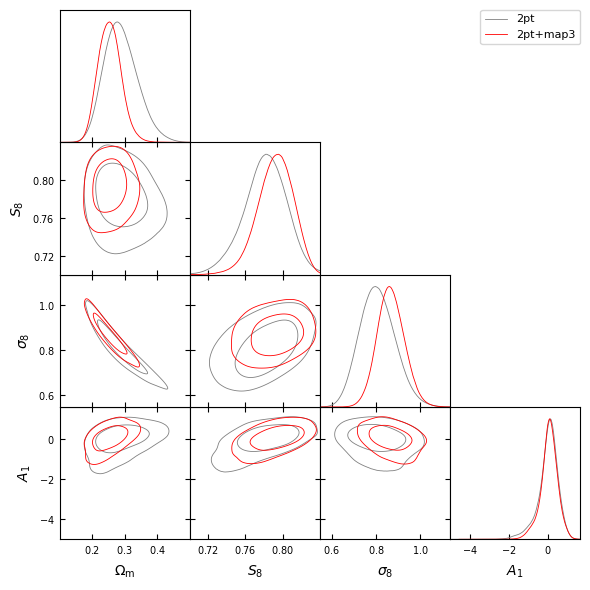

In [6]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twpt_all_sims, all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt', '2pt+map3'], legend_loc='upper right', 
    contour_colors=['gray', 'red'])
plt.show()

<Figure size 600x600 with 0 Axes>

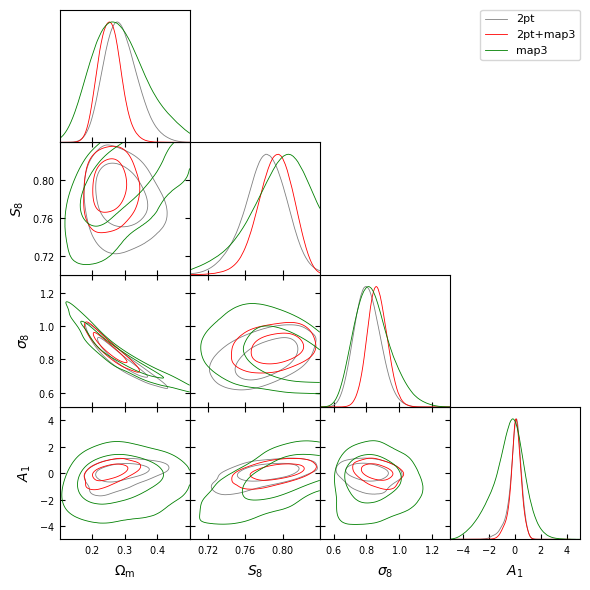

In [4]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twpt_all_sims, all_sims, map3_all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt', '2pt+map3', 'map3'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'green'])
plt.show()

<Figure size 600x600 with 0 Axes>

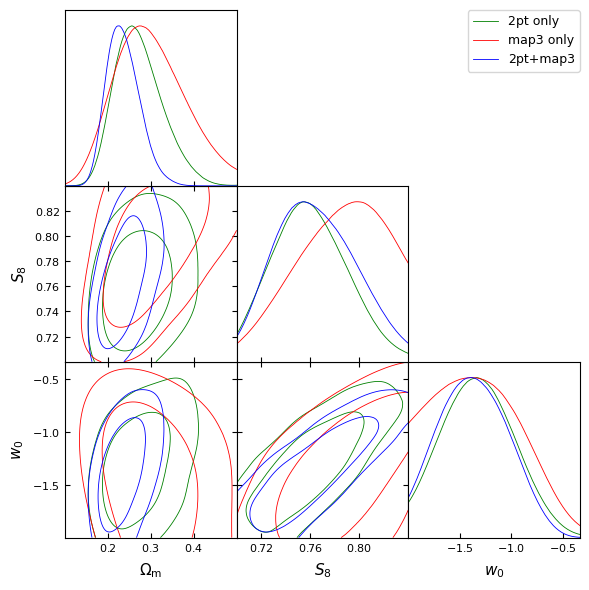

In [7]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twopoint_wCDM, map3_wCDM, all_sims_wCDM], ['om', 's8', 'w0'], filled=False, \
    legend_labels=['2pt only', 'map3 only', '2pt+map3'], legend_loc='upper right', 
    contour_colors=['green', 'red', 'blue'])
plt.show()

In [8]:
fom_2pt = utils.FoM_from_samples_names(twpt_all_sims, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(auto_all_sims, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(auto_334_344_all_sims, ['om', 's8'])
joint_fom = utils.FoM_from_samples_names(all_sims, ['om', 's8'])

fom_2pt_wcdm = utils.FoM_from_samples_names(twopoint_wCDM, ['s8', 'w0'])
joint_fom_wcdm = utils.FoM_from_samples_names(all_sims_wCDM, ['s8', 'w0'])

fom_2pt_oms8_wcdm = utils.FoM_from_samples_names(twopoint_wCDM, ['om', 's8'])
fom_all_oms8_wcdm = utils.FoM_from_samples_names(all_sims_wCDM, ['om', 's8'])

print(fom_2pt, fom_joint_auto)
print(fom_joint_auto/fom_2pt)
print(fom_2pt, fom_joint_auto_334_344)
print(fom_joint_auto_334_344/fom_2pt)
print(fom_2pt, joint_fom)
print(joint_fom/fom_2pt)

print(fom_2pt_wcdm, joint_fom_wcdm)
print(joint_fom_wcdm/fom_2pt_wcdm)

print(fom_2pt_oms8_wcdm, fom_all_oms8_wcdm)
print(fom_all_oms8_wcdm/fom_2pt_oms8_wcdm)

880.8530830483097 1121.063318979291
1.2727018166295128
880.8530830483097 1214.8631378706052
1.3791892896218392
880.8530830483097 1525.924085932343
1.732325305204903
153.48649798843988 163.12833331862888
1.0628187850824193
643.3336528114394 960.4139129034429
1.4928706258507194


In [125]:
# Get parameter names
param_names_all_sims = all_sims.getParamNames().names  # Correctly get the list of parameter names as strings

# Marginalized means
mean_all_sims = all_sims.getMeans()

# Marginalized standard deviations (uncertainties)
sigma_all_sims = [all_sims.std([param]) for param in param_names_all_sims]

# Repeat for the other chains
param_names_map3_all_sims = map3_all_sims.getParamNames().names
mean_map3_all_sims = map3_all_sims.getMeans()
sigma_map3_all_sims = [map3_all_sims.std([param]) for param in param_names_map3_all_sims]

param_names_twpt_all_sims = twpt_all_sims.getParamNames().names
mean_twpt_all_sims = twpt_all_sims.getMeans()
sigma_twpt_all_sims = [twpt_all_sims.std([param]) for param in param_names_twpt_all_sims]

# Print the marginalized means and uncertainties
print("Marginalized Means and Uncertainties for all_sims:")
for param, mean, sigma in zip(param_names_all_sims, mean_all_sims, sigma_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

print("\nMarginalized Means and Uncertainties for map3_all_sims:")
for param, mean, sigma in zip(param_names_map3_all_sims, mean_map3_all_sims, sigma_map3_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

print("\nMarginalized Means and Uncertainties for twpt_all_sims:")
for param, mean, sigma in zip(param_names_twpt_all_sims, mean_twpt_all_sims, sigma_twpt_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

Marginalized Means and Uncertainties for all_sims:
om	\Omega_{\rm m}: 0.2540 ± 0.0349
h0	h_0: 0.7193 ± 0.0829
cosmological_parameters--omega_b	cosmological_parameters--omega_b: 0.0474 ± 0.0099
cosmological_parameters--n_s	cosmological_parameters--n_s: 0.9694 ± 0.0517
s8	S_8: 0.7921 ± 0.0189
cosmological_parameters--mnu	cosmological_parameters--mnu: 0.2913 ± 0.1379
m1	m_1: -0.0064 ± 0.0081
m2	m_2: -0.0197 ± 0.0070
m3	m_3: -0.0247 ± 0.0067
m4	m_4: -0.0362 ± 0.0067
wl_photoz_errors--bias_1	wl_photoz_errors--bias_1: -0.0020 ± 0.0137
wl_photoz_errors--bias_2	wl_photoz_errors--bias_2: -0.0011 ± 0.0105
wl_photoz_errors--bias_3	wl_photoz_errors--bias_3: -0.0010 ± 0.0088
wl_photoz_errors--bias_4	wl_photoz_errors--bias_4: 0.0031 ± 0.0135
a1	A_1: 0.0504 ± 0.4452
alpha1	\alpha_1: 2.2085 ± 1.9609
sig8	\sigma_8: 0.8668 ± 0.0609
COSMOLOGICAL_PARAMETERS--SIGMA_12	COSMOLOGICAL_PARAMETERS--SIGMA_12: 0.8286 ± 0.0658
2pt-chi2	\chi^2_{\rm 2pt}: 502.9306 ± 28.3949
map3-chi2	\chi^2_{\rm map3}: 1.6505 ± 1.438

/var/folders/3n/q7th8cxj5rg_cz1qx6jv3pq80000gn/T/ipykernel_2109/594647047.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")
/var/folders/3n/q7th8cxj5rg_cz1qx6jv3pq80000gn/T/ipykernel_2109/594647047.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")
/var/folders/3n/q7th8cxj5rg_cz1qx6jv3pq80000gn/T/ipykernel_2109/594647047.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation.

In [12]:
# Define the parameters you're interested in
params = ['om', 's8', 'h0', 'cosmological_parameters--n_s', 'cosmological_parameters--omega_b', 'cosmological_parameters--mnu', 'w0']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    v1 = twopoint_wCDM.confidence(param, 0.16, upper=False)
    v2 = twopoint_wCDM.confidence(param, 0.16, upper=True)
    
    # Compute the peak (mean)
    peak = twopoint_wCDM.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

Parameter: om
Peak: [ 2.72345972e-01  7.12183177e-01  4.83397004e-02  9.69850746e-01
 -1.31197632e+00  7.60188997e-01  3.21613466e-01 -6.76319951e-03
 -1.98724358e-02 -2.48379303e-02 -3.61438912e-02 -5.21397508e-04
 -3.10278745e-04 -1.25051416e-03  3.45728811e-03 -1.01696282e-02
  2.21688797e+00  8.09358187e-01  7.77488666e-01  2.05298212e+01
             nan  3.02086864e+01 -2.19620963e+00  2.80124768e+01
  3.91865692e-04]
1-sigma Lower: 0.21735037272807933
1-sigma Upper: 0.3282397047167731
Parameter: s8
Peak: [ 2.72345972e-01  7.12183177e-01  4.83397004e-02  9.69850746e-01
 -1.31197632e+00  7.60188997e-01  3.21613466e-01 -6.76319951e-03
 -1.98724358e-02 -2.48379303e-02 -3.61438912e-02 -5.21397508e-04
 -3.10278745e-04 -1.25051416e-03  3.45728811e-03 -1.01696282e-02
  2.21688797e+00  8.09358187e-01  7.77488666e-01  2.05298212e+01
             nan  3.02086864e+01 -2.19620963e+00  2.80124768e+01
  3.91865692e-04]
1-sigma Lower: 0.7294733738578227
1-sigma Upper: 0.7908108457405525
Paramet

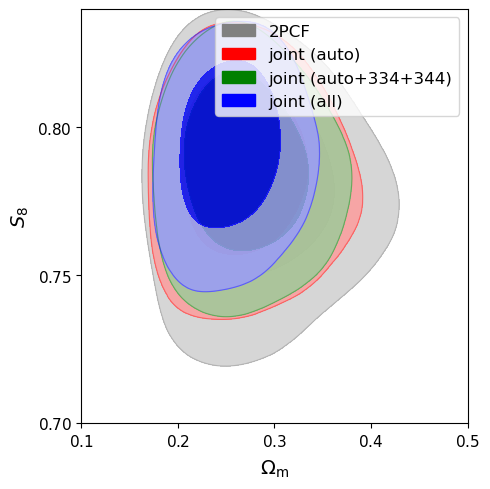

In [24]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([twpt_all_sims, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8], markers={'om': 0.26, 's8':0.782})
g.add_legend(['2PCF', 'joint (auto)', 'joint (auto+334+344)', 'joint (all)'], legend_loc='upper right')
#plt.savefig("../plots/all_500_sims_dv_results.png")
plt.show()

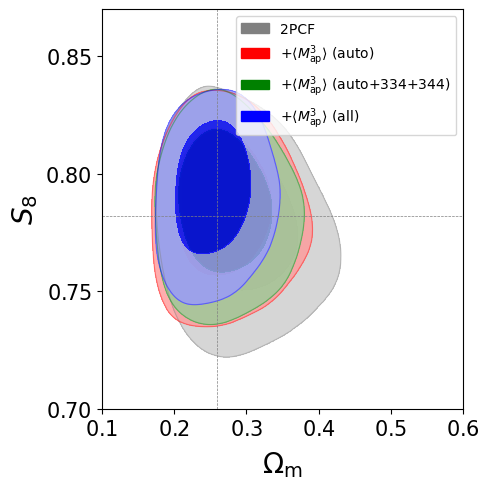

In [129]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (auto+334+344)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
g.export('../plots/contour2d_cosmogrid_dv_and_cov_19Sep24.pdf')

(0.7, 0.87)

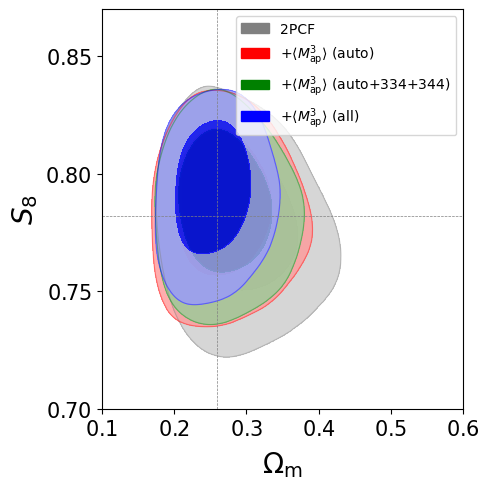

In [111]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims_update, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (auto+334+344)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

(0.7, 0.87)

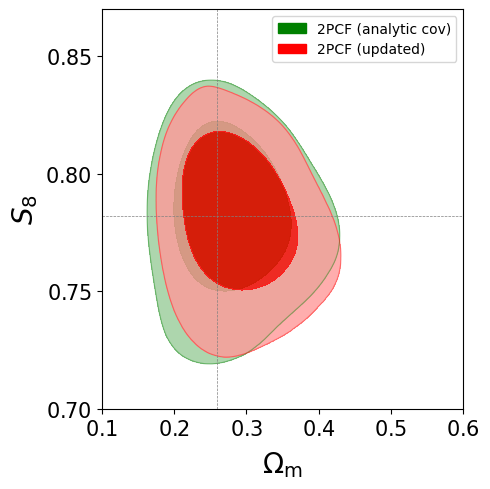

In [117]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims, twpt_all_sims_update], 'om', 's8', filled=True, 
    colors=['green','red'], alphas=[0.8,0.8])
g.add_legend(['2PCF (analytic cov)','2PCF (updated)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

(0.7, 0.87)

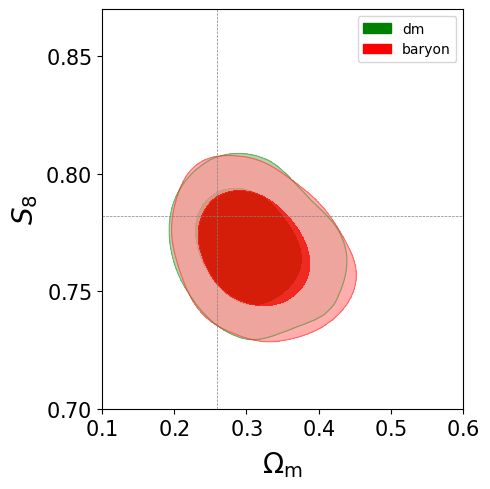

In [7]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([desy3_dm, desy3_baryon], 'om', 's8', filled=True, 
    colors=['green','red'], alphas=[0.8,0.8])
g.add_legend(['dm','baryon'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

In [11]:
# Define the parameters you're interested in
params = ['om', 's8', 'h0', 'cosmological_parameters--n_s', 'cosmological_parameters--omega_b', 'cosmological_parameters--mnu', 'w0']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    v1 = desy3_baryon.confidence(param, 0.16, upper=False)
    v2 = desy3_baryon.confidence(param, 0.16, upper=True)
    
    # Compute the peak (mean)
    peak = desy3_baryon.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

Parameter: om
Peak: [ 3.11811132e-01  6.99631151e-01  4.83524633e-02  9.60303404e-01
  7.67736550e-01  3.18639735e-01 -6.73924875e-03 -1.99557490e-02
 -2.47651895e-02 -3.56975165e-02 -5.80476726e-03 -1.56044628e-03
 -8.06412065e-04  4.87099649e-03  9.56276109e-01 -5.98029089e-01
  7.60872429e-01  7.38559439e-01  5.44836034e+00  6.32118670e-01
  3.05633791e+01 -2.54020477e+00  2.80231743e+01  3.57225962e-04]
1-sigma Lower: 0.26160405924061425
1-sigma Upper: 0.36198040039844126
Parameter: s8
Peak: [ 3.11811132e-01  6.99631151e-01  4.83524633e-02  9.60303404e-01
  7.67736550e-01  3.18639735e-01 -6.73924875e-03 -1.99557490e-02
 -2.47651895e-02 -3.56975165e-02 -5.80476726e-03 -1.56044628e-03
 -8.06412065e-04  4.87099649e-03  9.56276109e-01 -5.98029089e-01
  7.60872429e-01  7.38559439e-01  5.44836034e+00  6.32118670e-01
  3.05633791e+01 -2.54020477e+00  2.80231743e+01  3.57225962e-04]
1-sigma Lower: 0.7518285717512495
1-sigma Upper: 0.7837484365150394
Parameter: h0
Peak: [ 3.11811132e-01  6.

ParamError: Unknown parameter w0

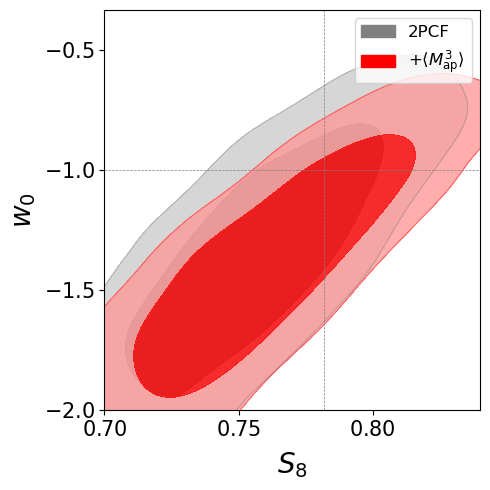

In [10]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twopoint_wCDM, all_sims_wCDM], 's8', 'w0', filled=True, 
    colors=['gray', 'red', 'blue', 'green'], alphas=[0.8, 0.8, 0.8])
g.add_legend([r'2PCF', r'+$\langle M_{\rm ap}^3\rangle$'], legend_loc='upper right')
g.add_x_marker(0.782)
g.add_y_marker(-1.0)
#plt.suptitle(r'$w$CDM', y=1.02, x = 0.59, fontsize=14)
plt.savefig('../plots/wCDM_contour2d_cosmogrid_dv_and_cov_25Sep24.pdf')

In [ ]:
import numpy as np

# Load the MCMC samples from your file
# Assuming your file is a space-separated text file with columns corresponding to parameters and log-posterior
data1 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim1.txt')
data2 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim2.txt')
data3 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim3.txt')

data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-all.txt')
map3_data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-map3-all.txt')
twpt_data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-500simcov.txt')

log_posterior = twpt_data_all[:, -2]
parameters = twpt_data_all[:, :-2]

# Find the index of the sample with the highest log-posterior
best_fit_index = np.argmax(log_posterior)
best_fit_params = parameters[best_fit_index]

print("Best-fit parameters:")
for i, param_value in enumerate(best_fit_params):
    print(f"Parameter {i}: {param_value:.5f}")

In [12]:
thpt1 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim1-cosmogrid.fits')
thpt2 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim2-cosmogrid.fits')
thpt3 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim3-cosmogrid.fits')
thpt_all = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-ave-cosmogrid_weighted.fits')

thpt_bf_sim1 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim1-BESTFIT.fits')
thpt_bf_sim2 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim2-BESTFIT.fits')
thpt_bf_sim3 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim3-BESTFIT.fits')
thpt_bf_all = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sims_all-BESTFIT.fits')

thpt_theo = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-theory-cosmogrid-params-Aug15.fits')
thpt_theo_huge_IA = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-theory-cosmogrid-params-huge_IA.fits')
thpt_bf_map3_all = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-map3-sims_all-BESTFIT.fits')

#thpt_theo_Nov = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-22Nov24-nocut_plus_sign.fits')
thpt_theo_Nov = threepoint.ThreePointDataClass.from_fits('../data/dv/test-emu-outlier-cosmo/sim_map3_model_cosmo2_change_fastnc_scheme2.fits')
thpt_theo_Nov_b = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_model_cosmo2_recomputed_NOV2024.fits')
thpt_theo_Nov_c = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_model_cosmo2_recomputed_NOV2024_c.fits')

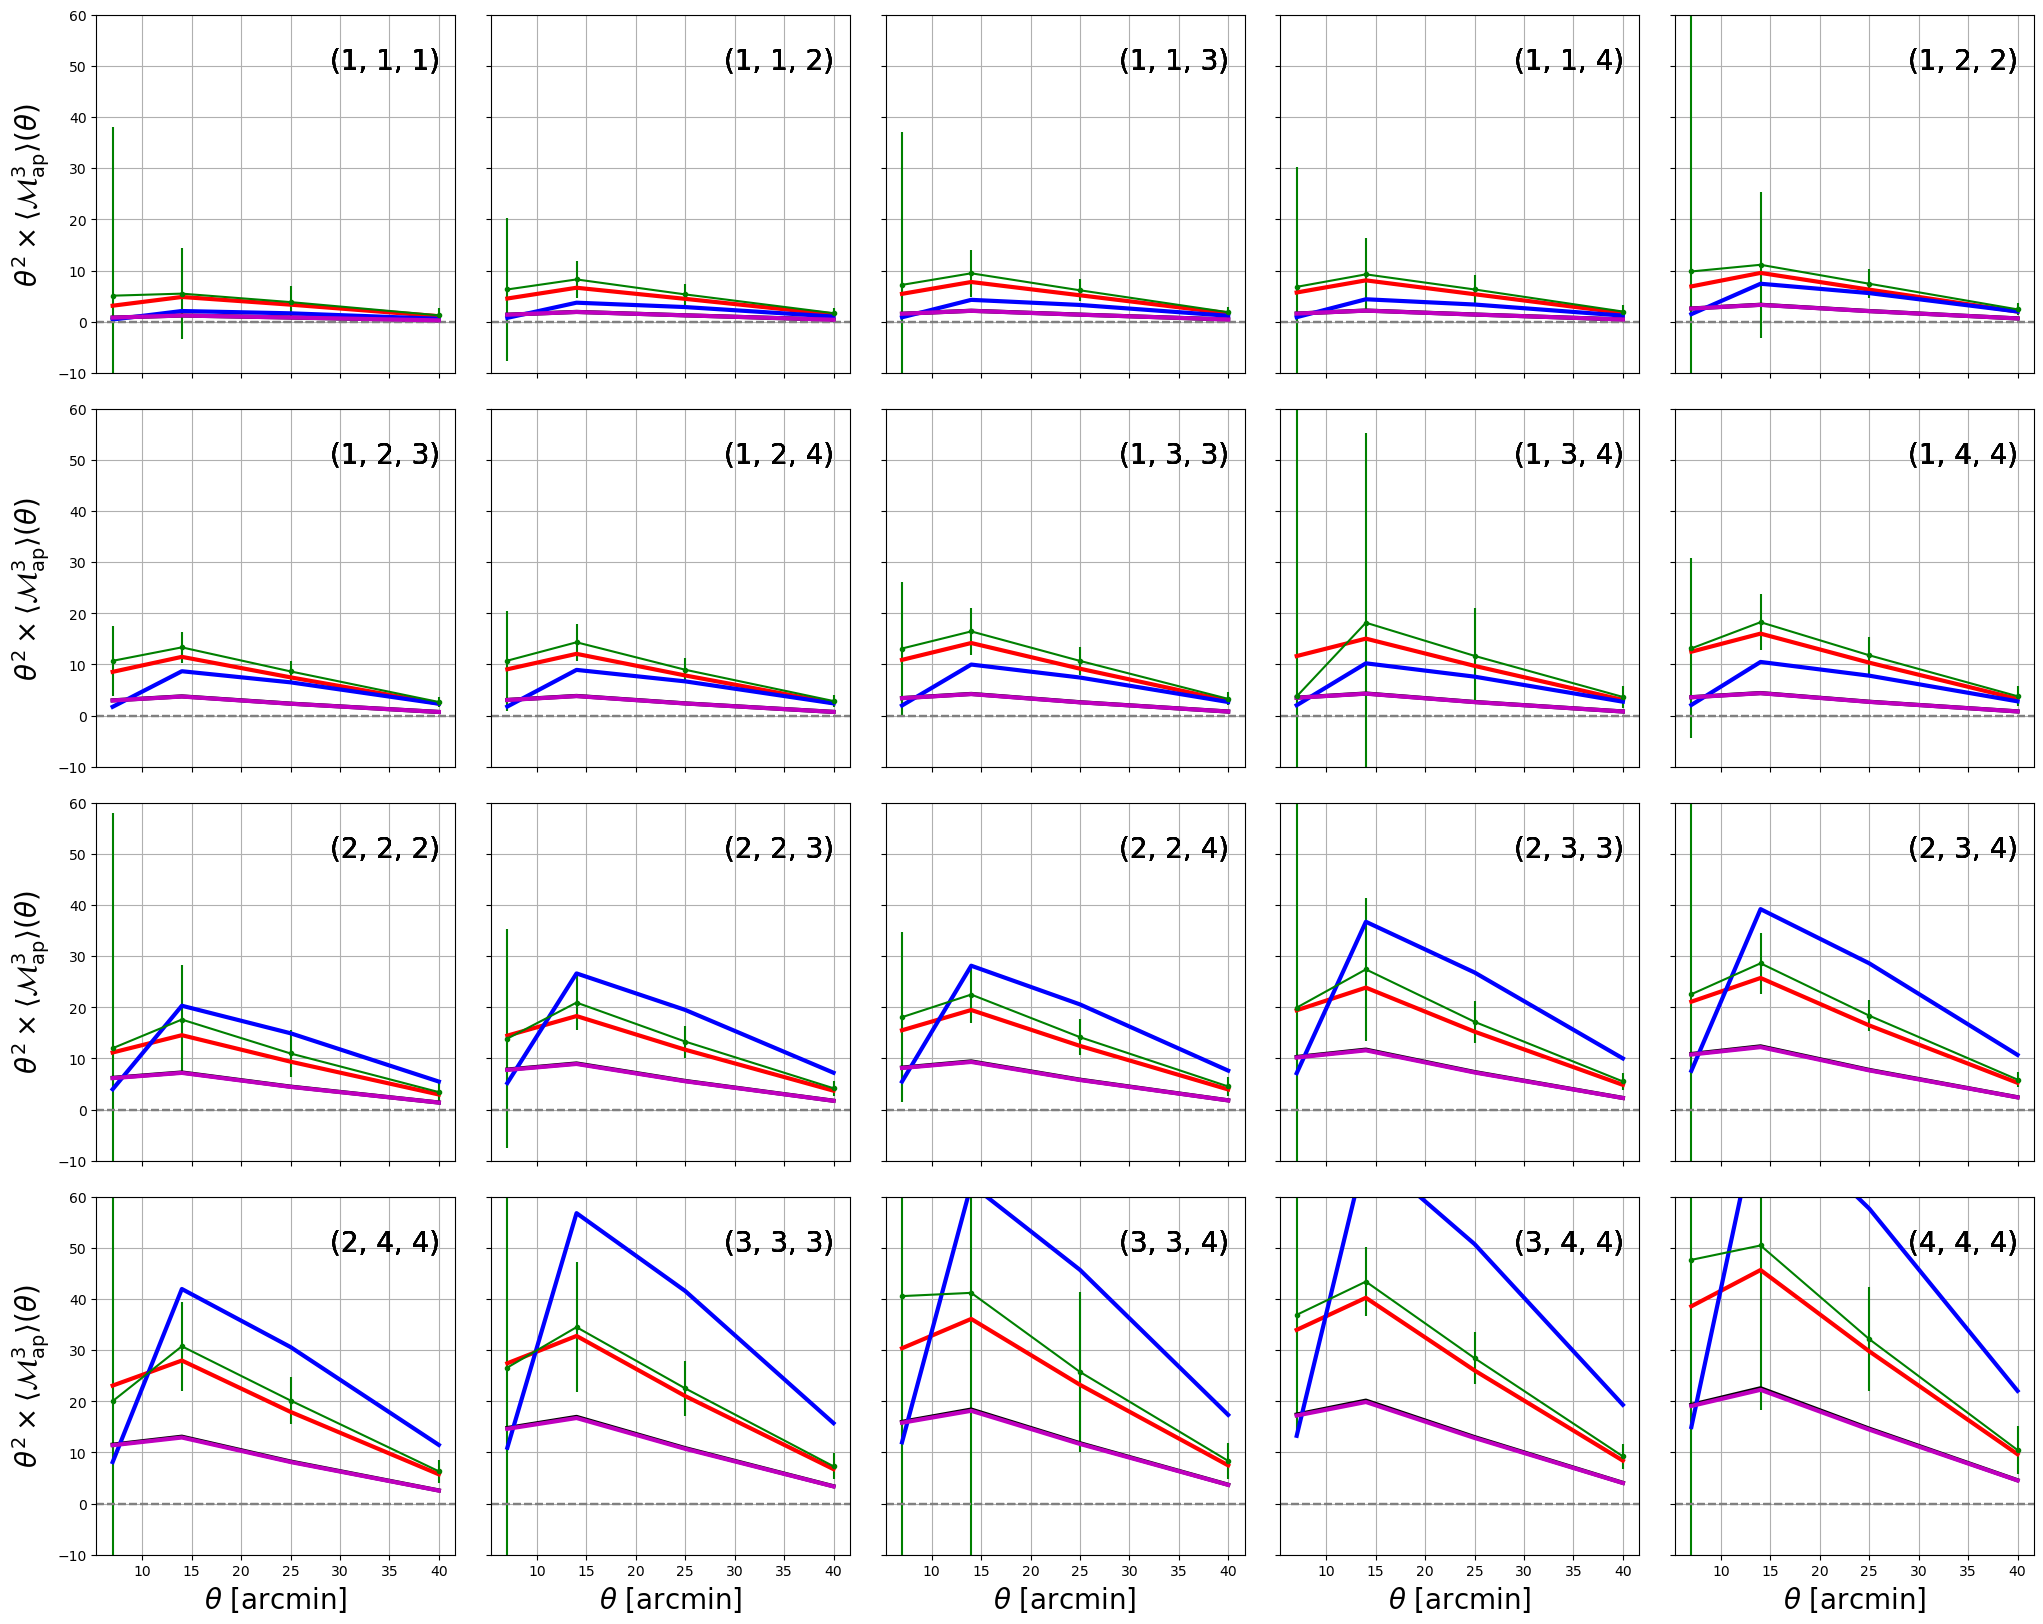

In [13]:
line_args = dict(color='g', ls='-')
fig, axes = thpt_all.plot2d(4, 5, figsize=(25, 20), **line_args)
#line_args2 = dict(color='C0', lw=3, ls=':')
#fig, axes = thpt_theo.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args2)
line_args2 = dict(color='r', lw=3, ls='-')
fig, axes = thpt_theo.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args2)
#line_args3 = dict(color='b', alpha=0.7, lw=2, ls='-')
#fig, axes = thpt_theo_huge_IA.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args3)
line_args4 = dict(color='k', lw=3, ls='-')
fig, axes = thpt_theo_Nov.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args4)
line_args5 = dict(color='b', lw=3, ls='-')
fig, axes = thpt_theo_Nov_b.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args5)
line_args6 = dict(color='m', lw=3, ls='-')
fig, axes = thpt_theo_Nov_c.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args6)
for ax in axes.flatten():
    ax.grid(True)
    ax.set_ylim(-10,60)
#plt.savefig("../plots/Map3_average_of_cosmogrid_sims_with_theory_and_IA_5Sep24.png")
plt.show()

In [7]:
thpt_all_8 = threepoint.ThreePointDataClass.from_fits('../data/dv/avg_map3-Cosmogrid-22Nov24-8arcmincut-WITH_COV.fits')
thpt_theo_8 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut.fits')
#thpt_theo_8_nobaryon = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut-nobaryon.fits')
thpt_theo_8_nobaryon = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits')
thpt_theo_huge_IA_8 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut-hugeIA-2.fits')

In [46]:
basefile = fits.open('../data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits')
nobaryon = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut-nobaryon.fits')
basefile.info()
nobaryon.info()
print(basefile[1].data)
print(nobaryon[1].data)
for i in range(80):
    basefile[1].data[i][6] = nobaryon[1].data[i][6]
print(basefile[1].data)
print(nobaryon[1].data)
new_file_path = '../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits'
basefile.writeto(new_file_path)

Filename: ../data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
Filename: ../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut-nobaryon.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
[(1, 1, 1,  7.,  7.,  7., 1.91966997e-10)
 (1, 1, 1, 14., 14., 14., 8.79050074e-11)
 (1, 1, 1, 25., 25., 25., 3.82239005e-11)
 (1, 1, 1, 40., 40., 40., 2.87543577e-12)
 (1, 1, 2,  7.,  7.,  7., 2.75008092e-10)
 (1, 1, 2, 14., 14., 14., 1.23340690e-10)
 (1, 1, 2, 25., 25., 25., 5.40051862e-11)
 (1, 1, 2, 40., 40., 40., 4.10267

In [48]:
base400simcov = fits.open('../data/dv/sim_map3-cosmoCosmogrid-8arcmincut-400SIMCOV_9Nov.fits')
newmap3 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits')

base400simcov.info()
newmap3.info()
for i in range(80):
    base400simcov[1].data[i][6] = newmap3[1].data[i][6]
    
new_file_path = '../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_400SIMCOV.fits'
base400simcov.writeto(new_file_path)

Filename: ../data/dv/sim_map3-cosmoCosmogrid-8arcmincut-400SIMCOV_9Nov.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
Filename: ../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [43]:
from astropy.io import fits
viewfile = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut.fits')
viewfile2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut-nobaryon.fits')
percentdiff = []
for i in range(80):
    x = viewfile[1].data[i][6]
    y = viewfile2[1].data[i][6]
    percentdiff.append(np.abs((x-y)/y))
print(percentdiff)

[0.02476075278949731, 0.021704121725114982, 0.015973483632316054, 0.011792598110933469, 0.02542629484282561, 0.02009775469702714, 0.014123137994147661, 0.01021565397526197, 0.025377811494262638, 0.019114324771412408, 0.013134970929575569, 0.009411987227510223, 0.025316669399001835, 0.01883360059537472, 0.012864819838394569, 0.009195912835952228, 0.025450523608167692, 0.01802086359197197, 0.011986681499754404, 0.00847651035412829, 0.024961797816205285, 0.01673260658149986, 0.010818706685052304, 0.007568872627624981, 0.024766498657243067, 0.01636394208102603, 0.01049784199928472, 0.0073234802855361774, 0.024098082228031437, 0.01519944655833541, 0.009507351399705074, 0.006573578974374551, 0.02376539538415121, 0.014744809236394903, 0.009135726656395395, 0.006296206075490676, 0.023351031143234606, 0.014237130887635513, 0.008729944183323473, 0.005996256936332127, 0.024699290411960277, 0.015459671451266109, 0.009600956794870167, 0.006622641551560523, 0.023662511031055822, 0.013853642089048903

In [45]:
thpt_all_5 = threepoint.ThreePointDataClass.from_fits('../data/dv/avg_map3-Cosmogrid-22Nov24-5arcmincut-WITH_COV_AT_8ARCMINCUT.fits')
thpt_theo_5 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-22Nov24-5arcmincut_plus_sign.fits')

In [73]:
from astropy.io import fits
base_file = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-22Nov24-nocut-oldfastnc.fits')
print(base_file[1].data)
for i in range(80):
    base_file[1].data[i][6] = -1*base_file[1].data[i][6]

print(base_file[1].data)
new_file_path = '../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-22Nov24-nocut-oldfastnc_plus_sign.fits'
base_file.writeto(new_file_path)

[(1, 1, 1,  7.,  7.,  7., -3.55821959e-10)
 (1, 1, 1, 14., 14., 14., -3.89680084e-10)
 (1, 1, 1, 25., 25., 25., -1.02566970e-10)
 (1, 1, 1, 40., 40., 40., -1.80690316e-11)
 (1, 1, 2,  7.,  7.,  7., -5.35826686e-10)
 (1, 1, 2, 14., 14., 14., -5.81217026e-10)
 (1, 1, 2, 25., 25., 25., -1.52022232e-10)
 (1, 1, 2, 40., 40., 40., -2.69427842e-11)
 (1, 1, 3,  7.,  7.,  7., -6.59510500e-10)
 (1, 1, 3, 14., 14., 14., -7.11514864e-10)
 (1, 1, 3, 25., 25., 25., -1.85629061e-10)
 (1, 1, 3, 40., 40., 40., -3.29915551e-11)
 (1, 1, 4,  7.,  7.,  7., -6.96722864e-10)
 (1, 1, 4, 14., 14., 14., -7.50553342e-10)
 (1, 1, 4, 25., 25., 25., -1.95713486e-10)
 (1, 1, 4, 40., 40., 40., -3.48078147e-11)
 (1, 2, 2,  7.,  7.,  7., -8.54204314e-10)
 (1, 2, 2, 14., 14., 14., -9.16832993e-10)
 (1, 2, 2, 25., 25., 25., -2.38494277e-10)
 (1, 2, 2, 40., 40., 40., -4.25116561e-11)
 (1, 2, 3,  7.,  7.,  7., -1.09315725e-09)
 (1, 2, 3, 14., 14., 14., -1.16607489e-09)
 (1, 2, 3, 25., 25., 25., -3.02761294e-10)
 (1, 2, 3, 

In [44]:
from astropy.io import fits
base_file = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-22Nov24-5arcmincut.fits')
print(base_file[1].data)
for i in range(80):
    base_file[1].data[i][6] = -1*base_file[1].data[i][6]

print(base_file[1].data)
#new_file_path = '../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-22Nov24-5arcmincut_plus_sign.fits'
#base_file.writeto(new_file_path)

[(1, 1, 1,  7.,  7.,  7., -2.06686803e-10)
 (1, 1, 1, 14., 14., 14., -1.38569664e-10)
 (1, 1, 1, 25., 25., 25., -5.93482302e-11)
 (1, 1, 1, 40., 40., 40., -4.41743855e-12)
 (1, 1, 2,  7.,  7.,  7., -2.99860764e-10)
 (1, 1, 2, 14., 14., 14., -1.97479116e-10)
 (1, 1, 2, 25., 25., 25., -8.54766756e-11)
 (1, 1, 2, 40., 40., 40., -6.38808120e-12)
 (1, 1, 3,  7.,  7.,  7., -3.61171974e-10)
 (1, 1, 3, 14., 14., 14., -2.35587371e-10)
 (1, 1, 3, 25., 25., 25., -1.02674336e-10)
 (1, 1, 3, 40., 40., 40., -7.69714866e-12)
 (1, 1, 4,  7.,  7.,  7., -3.79171389e-10)
 (1, 1, 4, 14., 14., 14., -2.46703655e-10)
 (1, 1, 4, 25., 25., 25., -1.07748634e-10)
 (1, 1, 4, 40., 40., 40., -8.08623770e-12)
 (1, 2, 2,  7.,  7.,  7., -4.58316084e-10)
 (1, 2, 2, 14., 14., 14., -2.95956949e-10)
 (1, 2, 2, 25., 25., 25., -1.29824113e-10)
 (1, 2, 2, 40., 40., 40., -9.75795770e-12)
 (1, 2, 3,  7.,  7.,  7., -5.71511145e-10)
 (1, 2, 3, 14., 14., 14., -3.65070260e-10)
 (1, 2, 3, 25., 25., 25., -1.61633805e-10)
 (1, 2, 3, 

OSError: File ../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-22Nov24-5arcmincut_plus_sign.fits already exists. If you mean to replace it then use the argument "overwrite=True".

In [42]:
from astropy.io import fits
base_file = fits.open('../data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits')
measured_8arcmin = np.load('../data/dv/map3_average_5arcmincut_maxn100.npy')
print(base_file[1].data)
for i in range(80):
    base_file[1].data[i][6] = measured_8arcmin[i]

print(base_file[1].data)
#new_file_path = '../data/dv/avg_map3-Cosmogrid-22Nov24-5arcmincut-WITH_COV_AT_8ARCMINCUT.fits'
#base_file.writeto(new_file_path)

[(1, 1, 1,  7.,  7.,  7., 1.91966997e-10)
 (1, 1, 1, 14., 14., 14., 8.79050074e-11)
 (1, 1, 1, 25., 25., 25., 3.82239005e-11)
 (1, 1, 1, 40., 40., 40., 2.87543577e-12)
 (1, 1, 2,  7.,  7.,  7., 2.75008092e-10)
 (1, 1, 2, 14., 14., 14., 1.23340690e-10)
 (1, 1, 2, 25., 25., 25., 5.40051862e-11)
 (1, 1, 2, 40., 40., 40., 4.10267890e-12)
 (1, 1, 3,  7.,  7.,  7., 3.28840819e-10)
 (1, 1, 3, 14., 14., 14., 1.45769724e-10)
 (1, 1, 3, 25., 25., 25., 6.41676389e-11)
 (1, 1, 3, 40., 40., 40., 4.90122368e-12)
 (1, 1, 4,  7.,  7.,  7., 3.44537175e-10)
 (1, 1, 4, 14., 14., 14., 1.52231244e-10)
 (1, 1, 4, 25., 25., 25., 6.71338753e-11)
 (1, 1, 4, 40., 40., 40., 5.13568732e-12)
 (1, 2, 2,  7.,  7.,  7., 4.14235735e-10)
 (1, 2, 2, 14., 14., 14., 1.81393529e-10)
 (1, 2, 2, 25., 25., 25., 8.02333216e-11)
 (1, 2, 2, 40., 40., 40., 6.16253162e-12)
 (1, 2, 3,  7.,  7.,  7., 5.12037169e-10)
 (1, 2, 3, 14., 14., 14., 2.21066516e-10)
 (1, 2, 3, 25., 25., 25., 9.85917972e-11)
 (1, 2, 3, 40., 40., 40., 7.621672

OSError: File ../data/dv/avg_map3-Cosmogrid-22Nov24-5arcmincut-WITH_COV_AT_8ARCMINCUT.fits already exists. If you mean to replace it then use the argument "overwrite=True".

In [11]:
from astropy.io import fits
base_file = fits.open('../data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits')
measured_8arcmin = np.load('../data/dv/map3_average_8arcmincut_maxn100.npy')
print(base_file[1].data)
for i in range(80):
    base_file[1].data[i][6] = measured_8arcmin[i]

print(base_file[1].data)
#new_file_path = '../data/dv/avg_map3-Cosmogrid-22Nov24-8arcmincut-WITH_COV.fits'
#base_file.writeto(new_file_path)

[(1, 1, 1,  7.,  7.,  7., 1.91966997e-10)
 (1, 1, 1, 14., 14., 14., 8.79050074e-11)
 (1, 1, 1, 25., 25., 25., 3.82239005e-11)
 (1, 1, 1, 40., 40., 40., 2.87543577e-12)
 (1, 1, 2,  7.,  7.,  7., 2.75008092e-10)
 (1, 1, 2, 14., 14., 14., 1.23340690e-10)
 (1, 1, 2, 25., 25., 25., 5.40051862e-11)
 (1, 1, 2, 40., 40., 40., 4.10267890e-12)
 (1, 1, 3,  7.,  7.,  7., 3.28840819e-10)
 (1, 1, 3, 14., 14., 14., 1.45769724e-10)
 (1, 1, 3, 25., 25., 25., 6.41676389e-11)
 (1, 1, 3, 40., 40., 40., 4.90122368e-12)
 (1, 1, 4,  7.,  7.,  7., 3.44537175e-10)
 (1, 1, 4, 14., 14., 14., 1.52231244e-10)
 (1, 1, 4, 25., 25., 25., 6.71338753e-11)
 (1, 1, 4, 40., 40., 40., 5.13568732e-12)
 (1, 2, 2,  7.,  7.,  7., 4.14235735e-10)
 (1, 2, 2, 14., 14., 14., 1.81393529e-10)
 (1, 2, 2, 25., 25., 25., 8.02333216e-11)
 (1, 2, 2, 40., 40., 40., 6.16253162e-12)
 (1, 2, 3,  7.,  7.,  7., 5.12037169e-10)
 (1, 2, 3, 14., 14., 14., 2.21066516e-10)
 (1, 2, 3, 25., 25., 25., 9.85917972e-11)
 (1, 2, 3, 40., 40., 40., 7.621672

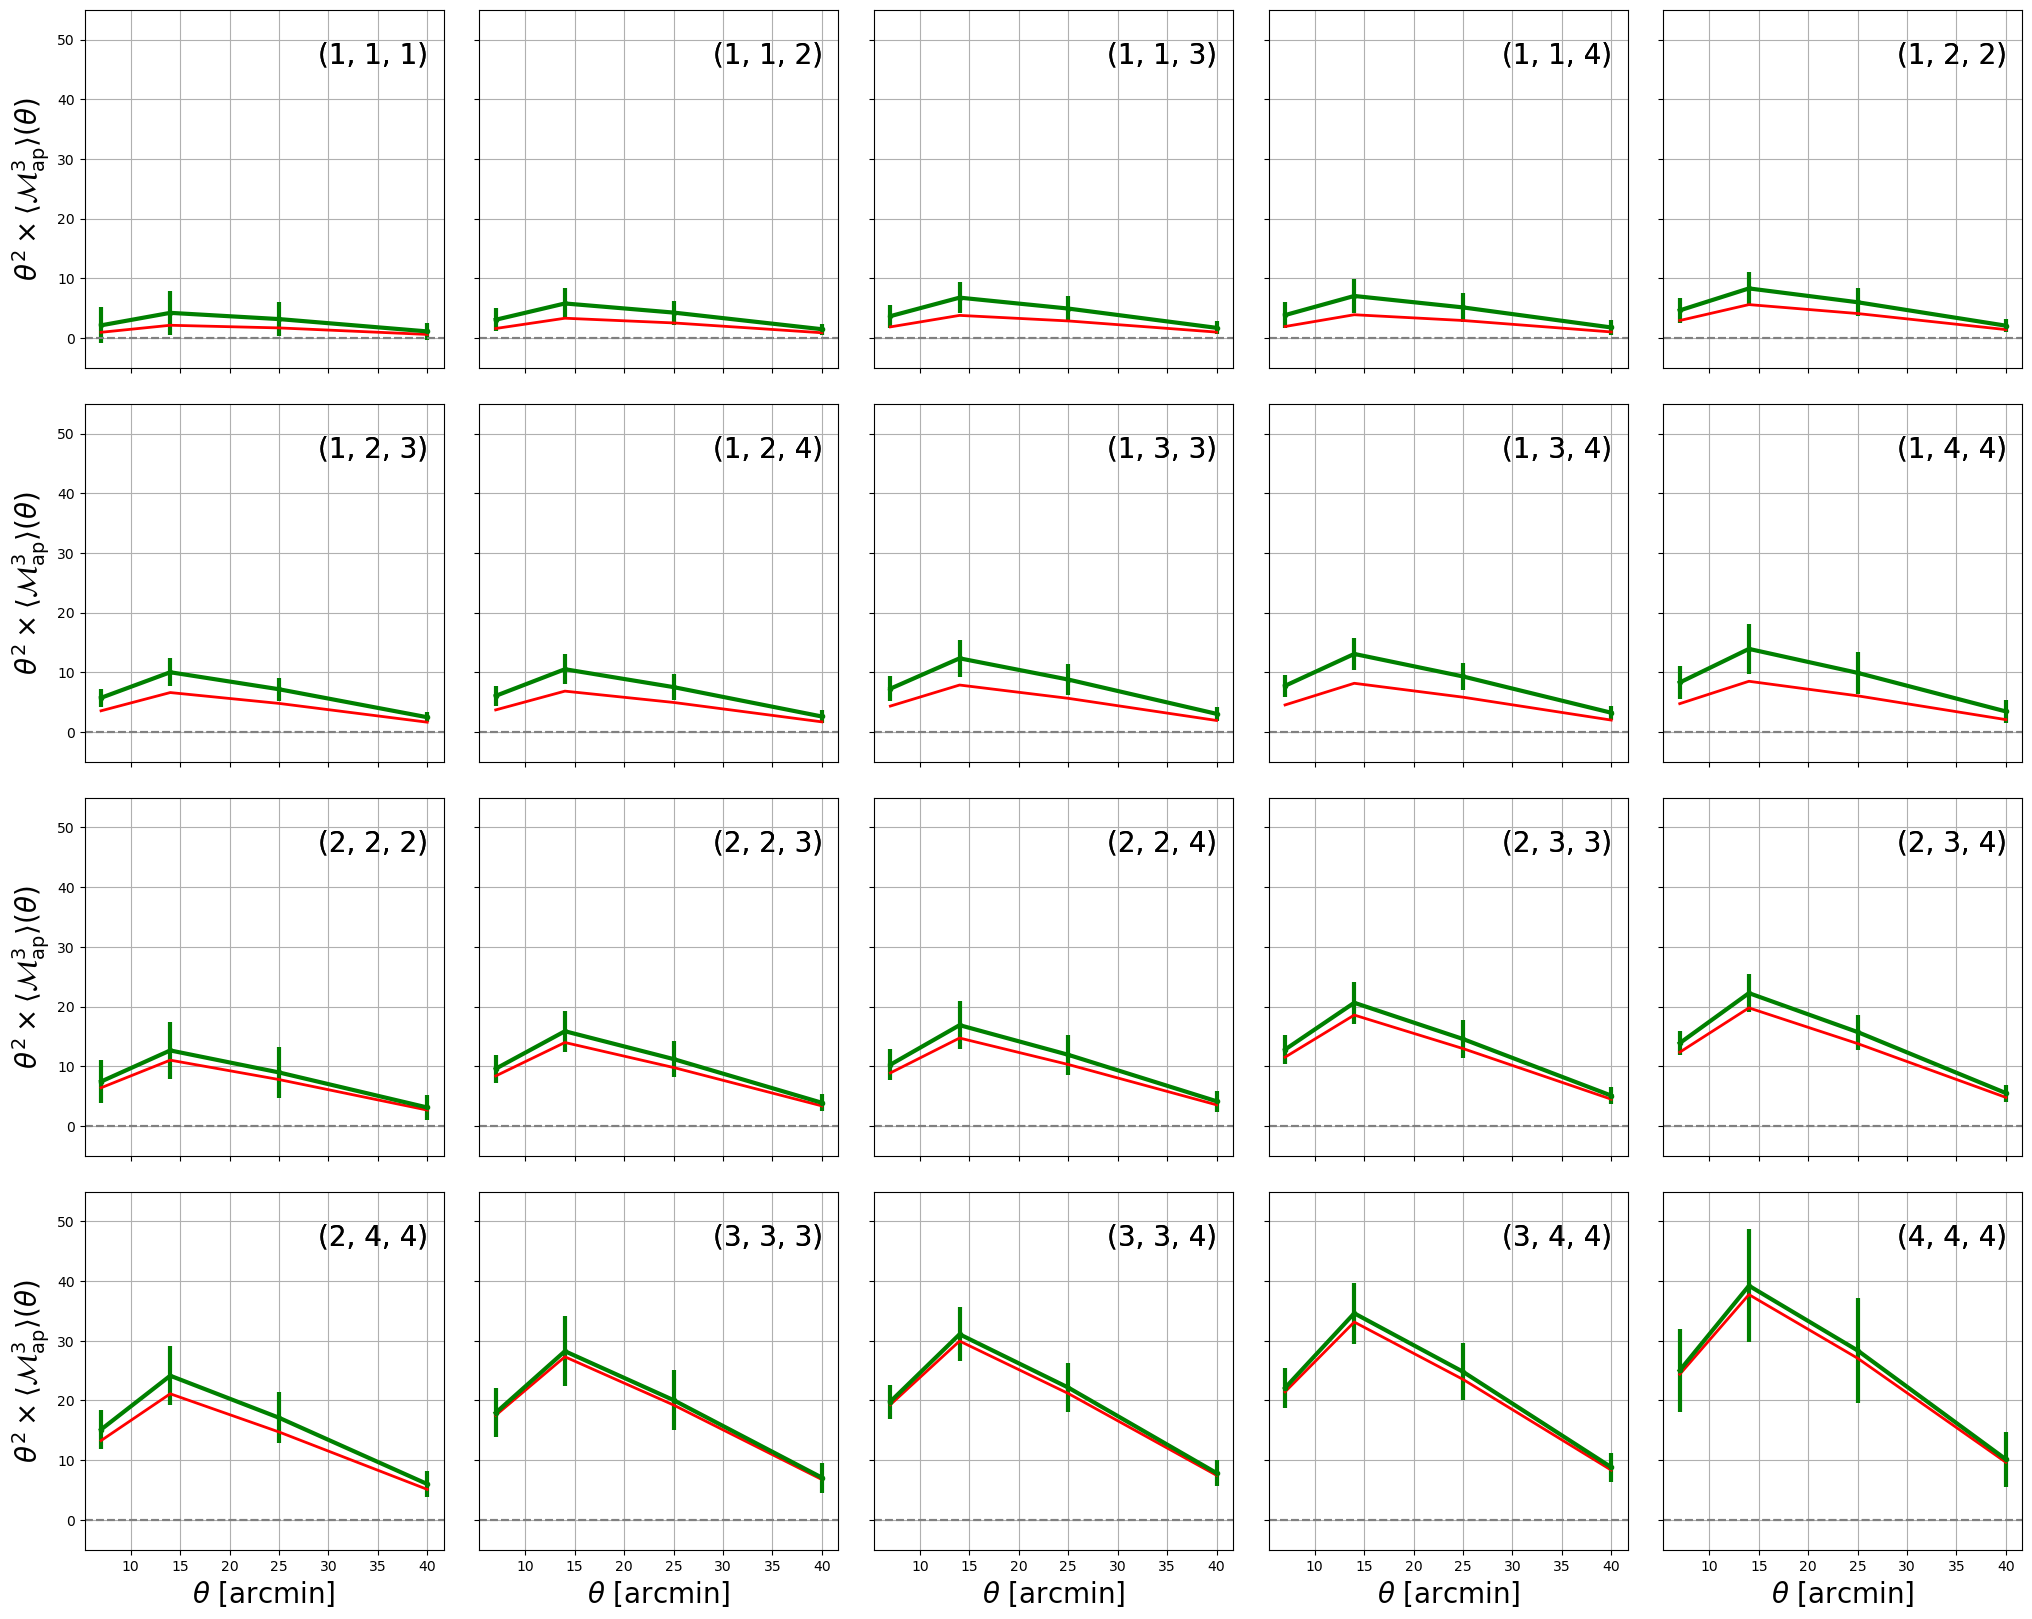

In [12]:
line_args4 = dict(color='g', lw=3, ls='-')
fig, axes = thpt_theo_8_nobaryon.plot2d(4, 5, figsize=(25,20), **line_args4)
#line_args4b = dict(color='darkorange', lw=3, ls='-')
#fig, axes = thpt_theo_8.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args4b)
line_args5 = dict(color='r', lw=2, ls='-')
fig, axes = thpt_theo_huge_IA_8.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args5)
for ax in axes.flatten():
    ax.grid(True)
    ax.set_ylim(-5,55)
#plt.savefig("../plots/Map3_average_of_cosmogrid_sims_with_theory_and_IA_22Nov24.png")
plt.show()

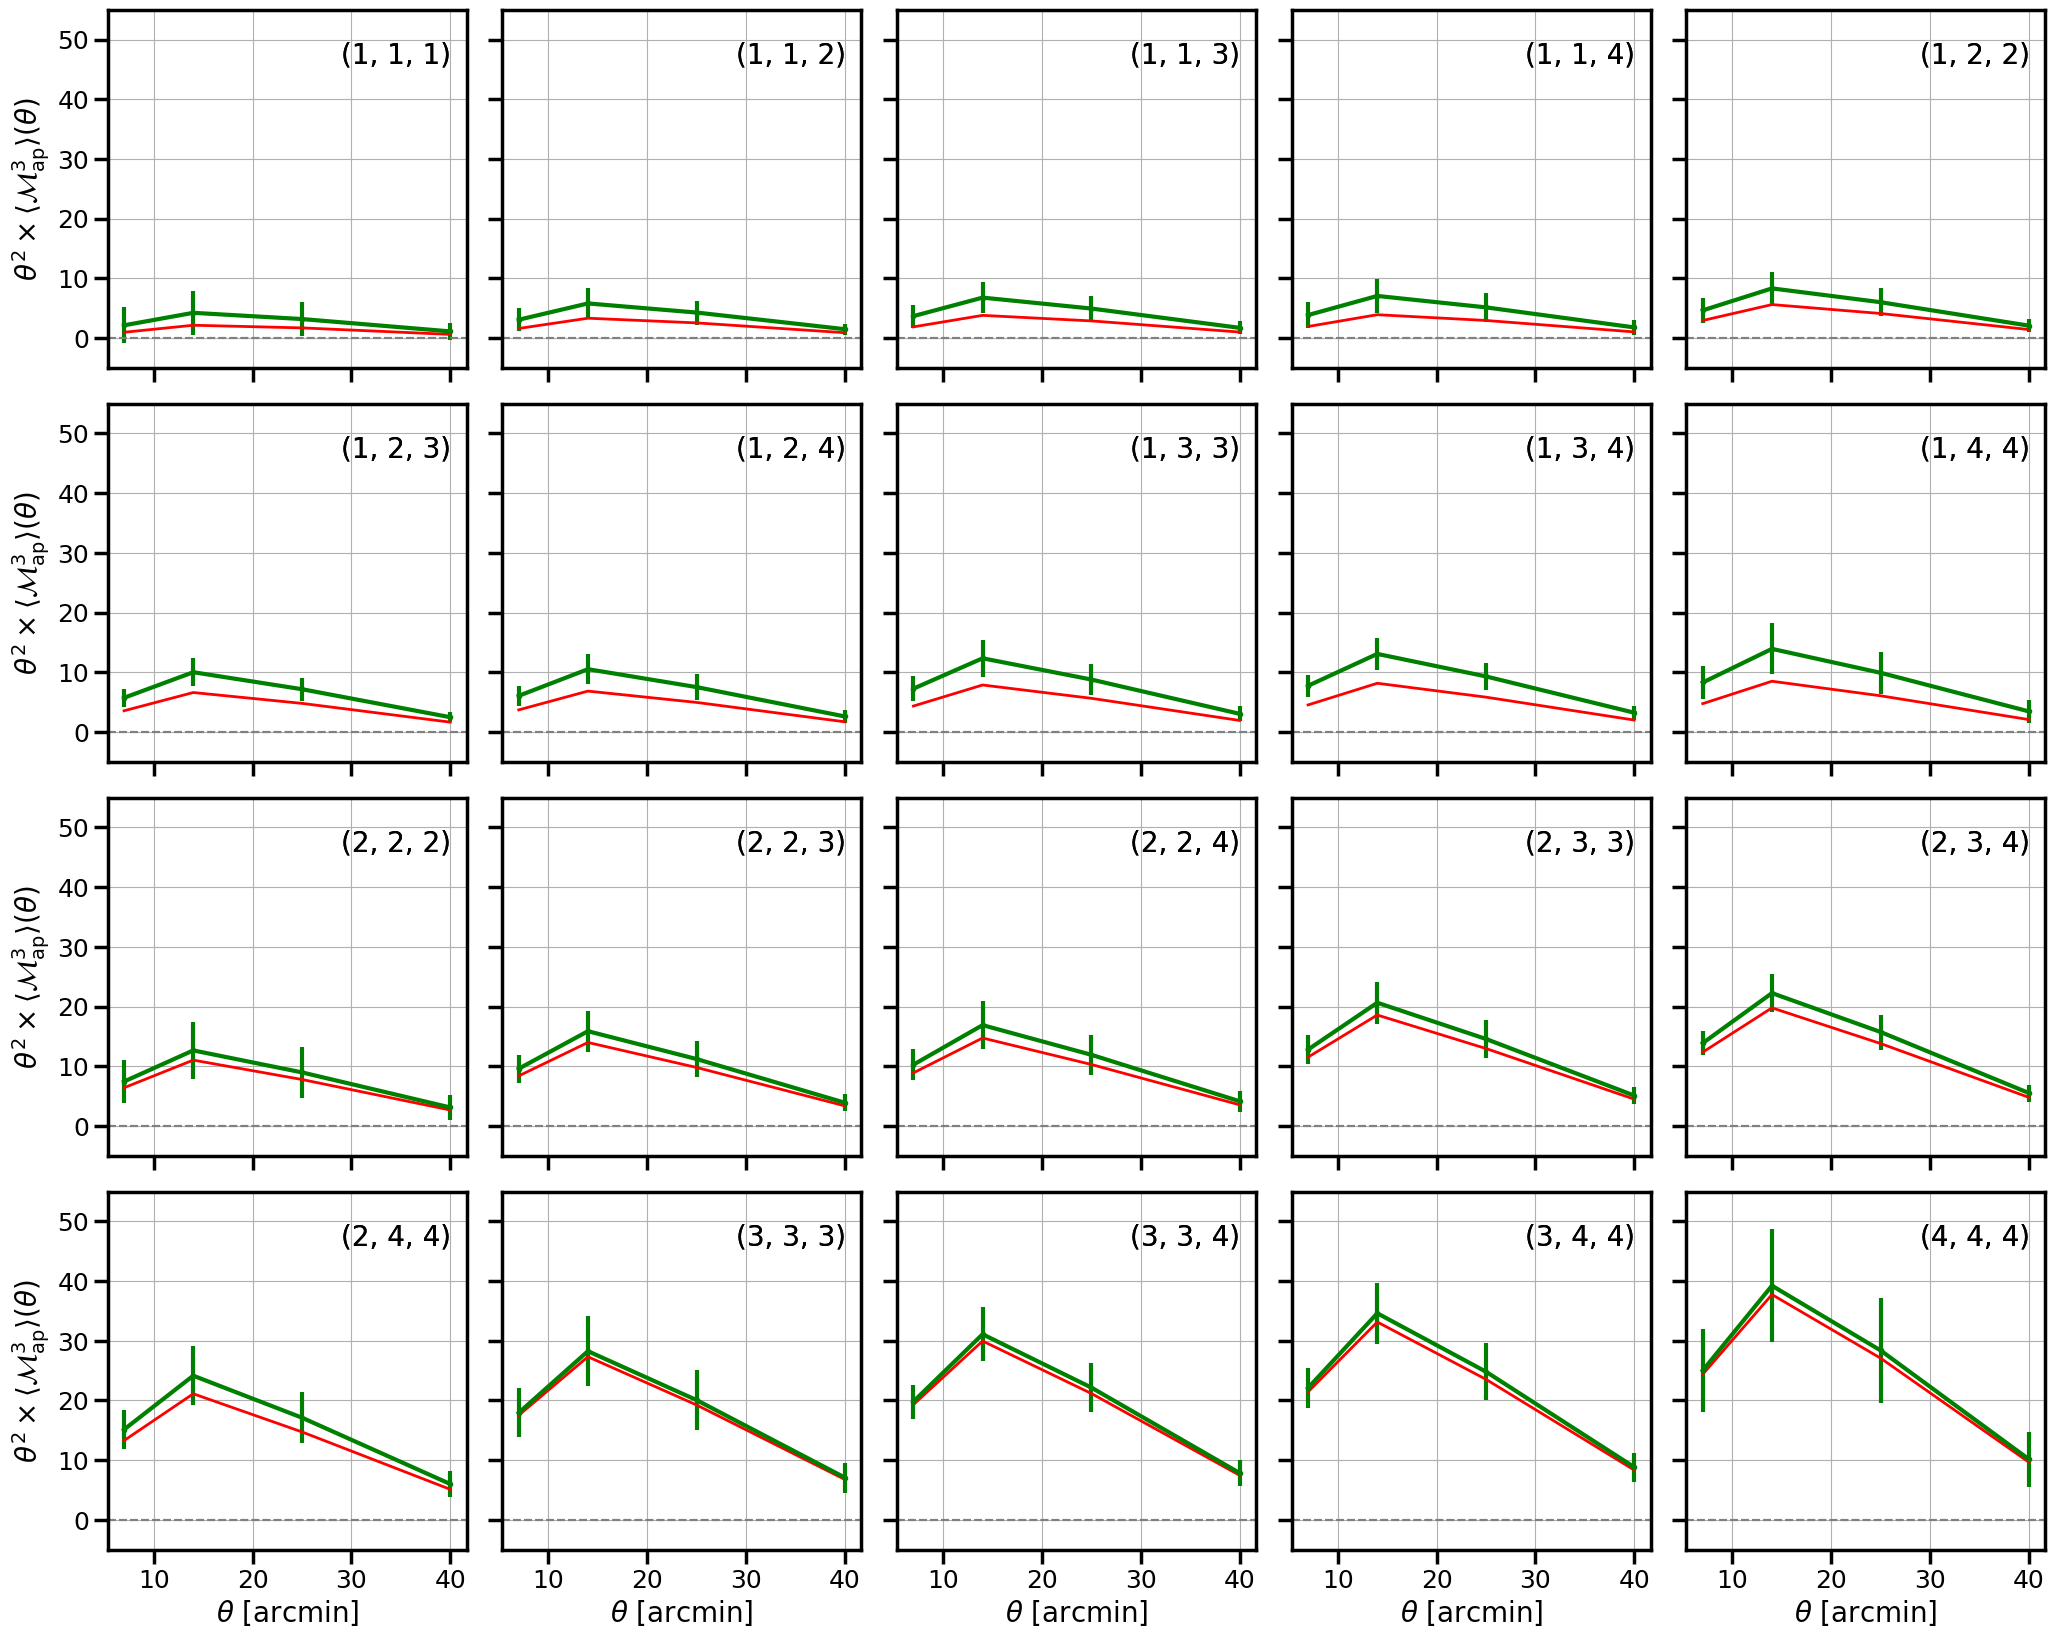

In [14]:
line_args4 = dict(color='g', lw=3, ls='-')
fig, axes = thpt_theo_8_nobaryon.plot2d(4, 5, figsize=(25, 20), **line_args4)

line_args5 = dict(color='r', lw=2, ls='-')
fig, axes = thpt_theo_huge_IA_8.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args5)

# Loop over axes and apply styling
for ax in axes.flatten():
    ax.grid(True)
    ax.set_ylim(-5, 55)

    # Make borders (spines) thicker
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)  # Adjust the linewidth as needed

    # Make ticks larger and thicker
    ax.tick_params(axis='both', which='major', labelsize=18, width=2.5, length=10)  # Larger major ticks
    ax.tick_params(axis='both', which='minor', labelsize=16, width=1.5, length=5)   # Minor ticks (optional)

#plt.show()
plt.savefig("Mass_aperture_data_vector_16Dec.pdf", dpi=600)

In [11]:
no_baryonic_signal = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits')
ratio_baryonic_signal = threepoint.ThreePointDataClass.from_fits('../data/dv/ratio_map3_OWLS_BARYON.fits')

In [10]:
from astropy.io import fits
nob = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits')
owls = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-13DECEMBER_OWLS_BARYON.fits')

#print(nob[1].data)
#print(owls[1].data)

ratio = np.zeros(80)
for i in range(80):
    ratio[i] = owls[1].data[i][6]/nob[1].data[i][6]
#    owls[1].data[i][6] = ratio[i]
print(ratio)
#newratiofile = '../data/dv/ratio_map3_OWLS_BARYON.fits'
#owls.writeto(newratiofile)

[1.04490167 1.03952921 1.02915973 1.02158358 1.04616489 1.0366323
 1.02582    1.01873642 1.04610168 1.03485855 1.02403893 1.0172861
 1.04599733 1.0343525  1.02355214 1.0168956  1.04625911 1.0328848
 1.02196818 1.01559867 1.04539572 1.03056205 1.01986629 1.01396108
 1.0450479  1.02989798 1.01928907 1.01351735 1.04385338 1.02780034
 1.01750902 1.0121636  1.04325746 1.02698247 1.01684096 1.01166057
 1.04251514 1.02607013 1.01611093 1.01111401 1.04494023 1.02826419
 1.01767313 1.01225582 1.04308145 1.02537153 1.01530084 1.010489
 1.04243015 1.02454645 1.01465216 1.01001179 1.04035248 1.02201479
 1.01271259 1.00860421 1.03938239 1.02102853 1.01198849 1.00808273
 1.03823632 1.01994916 1.01121362 1.00752748 1.03653051 1.01815982
 1.00993974 1.00663154 1.03513699 1.01699333 1.00914871 1.00607401
 1.03349692 1.01571578 1.00830571 1.00548274 1.03148731 1.01427008
 1.00738119 1.0048378 ]


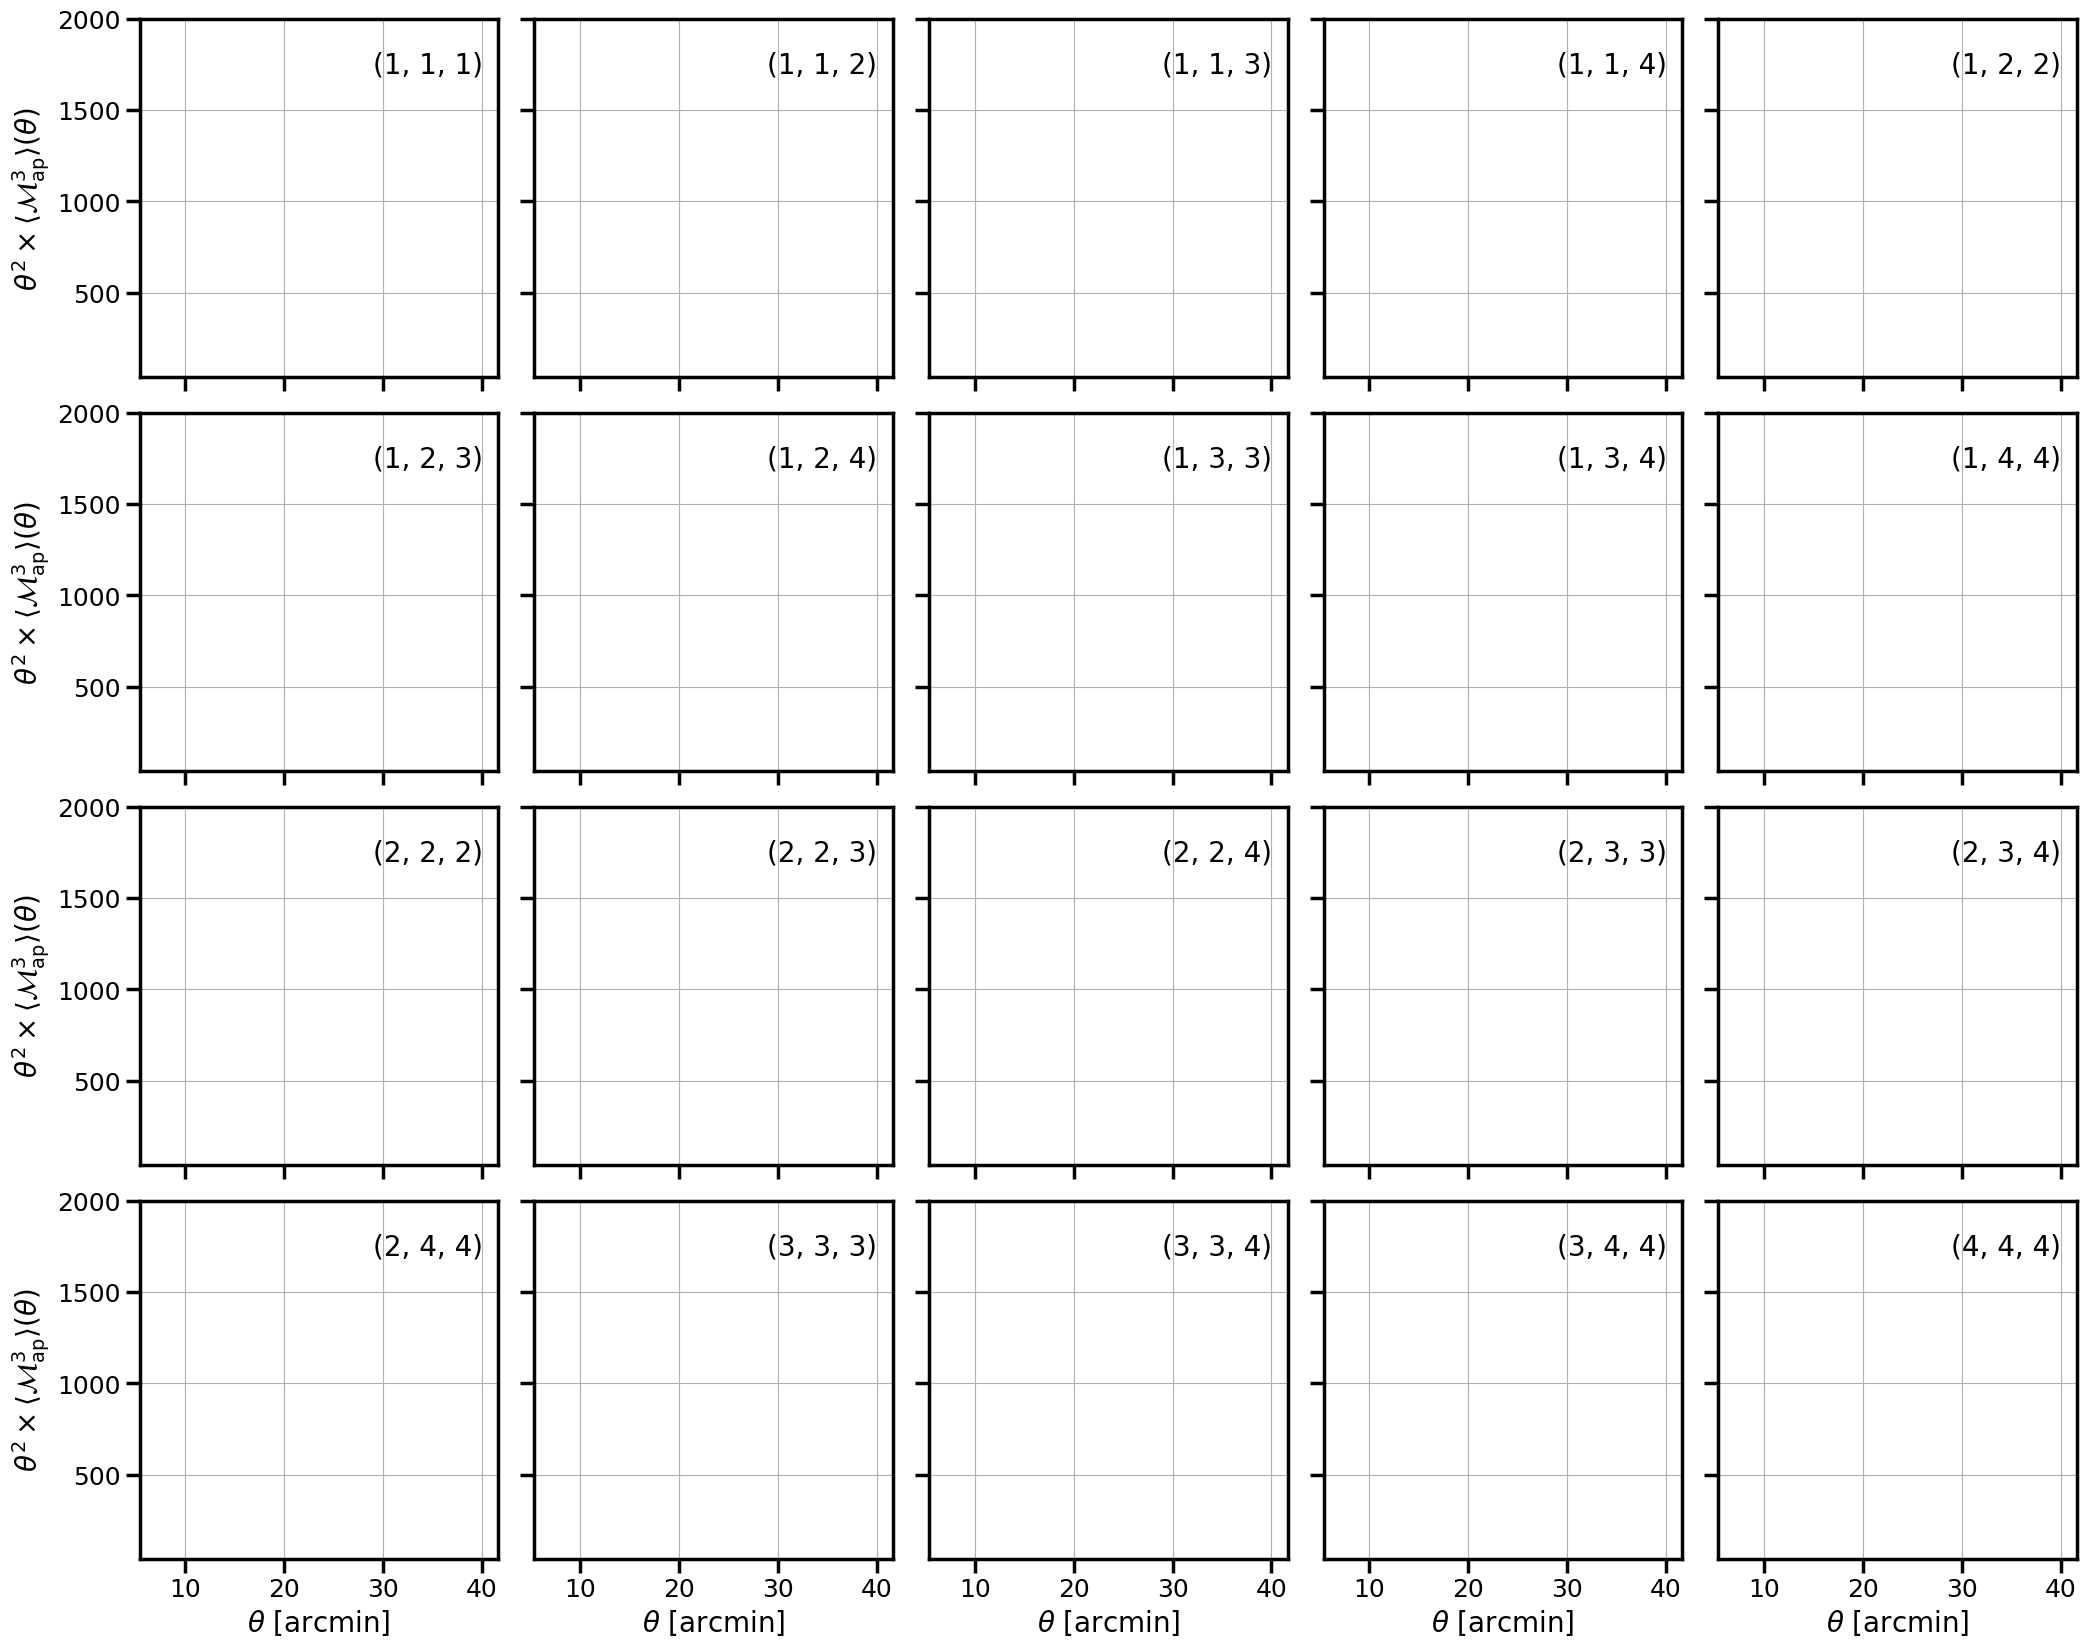

In [14]:
#baryon test
line_args4 = dict(color='g', lw=3, ls='-')
fig, axes = ratio_baryonic_signal.plot2d(4, 5, figsize=(25, 20), **line_args4)

#line_args5 = dict(color='r', lw=2, ls='-')
#fig, axes = owls_like_baryonic_signal.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args5)

# Loop over axes and apply styling
for ax in axes.flatten():
    ax.grid(True)
    ax.set_ylim(40, 2000)

    # Make borders (spines) thicker
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)  # Adjust the linewidth as needed

    # Make ticks larger and thicker
    ax.tick_params(axis='both', which='major', labelsize=18, width=2.5, length=10)  # Larger major ticks
    ax.tick_params(axis='both', which='minor', labelsize=16, width=1.5, length=5)   # Minor ticks (optional)

plt.show()

[0.68041367 0.76941026 0.9166111  1.00267774 0.67627372 0.78518098
 0.93466834 1.01369376 0.67648083 0.79594482 0.94484336 1.01899159
 0.67751222 0.79948905 0.94766012 1.02030922 0.67505201 0.80280271
 0.95322114 1.02422096 0.67735485 0.81531647 0.96402729 1.02923508
 0.6790247  0.81940475 0.96702738 1.03044391 0.68179443 0.83000839
 0.97571159 1.0340507  0.68450137 0.835118   0.97907698 1.03516188
 0.68880879 0.84138075 0.98273186 1.03618666 0.67668511 0.82152132
 0.97149885 1.03371278 0.68102764 0.83524563 0.98241451 1.03805411
 0.68329294 0.83969207 0.98543179 1.03903116 0.687447   0.85069685
 0.99379544 1.04186164 0.69070233 0.85597586 0.99702234 1.04261435
 0.69522455 0.8621286  1.00042461 1.04321672 0.6959416  0.86752883
 1.00529064 1.04478771 0.7002512  0.87355567 1.0085977  1.04515538
 0.7058299  0.88043515 1.01202017 1.04526689 0.71360581 0.8886365
 1.01555107 1.04494929]


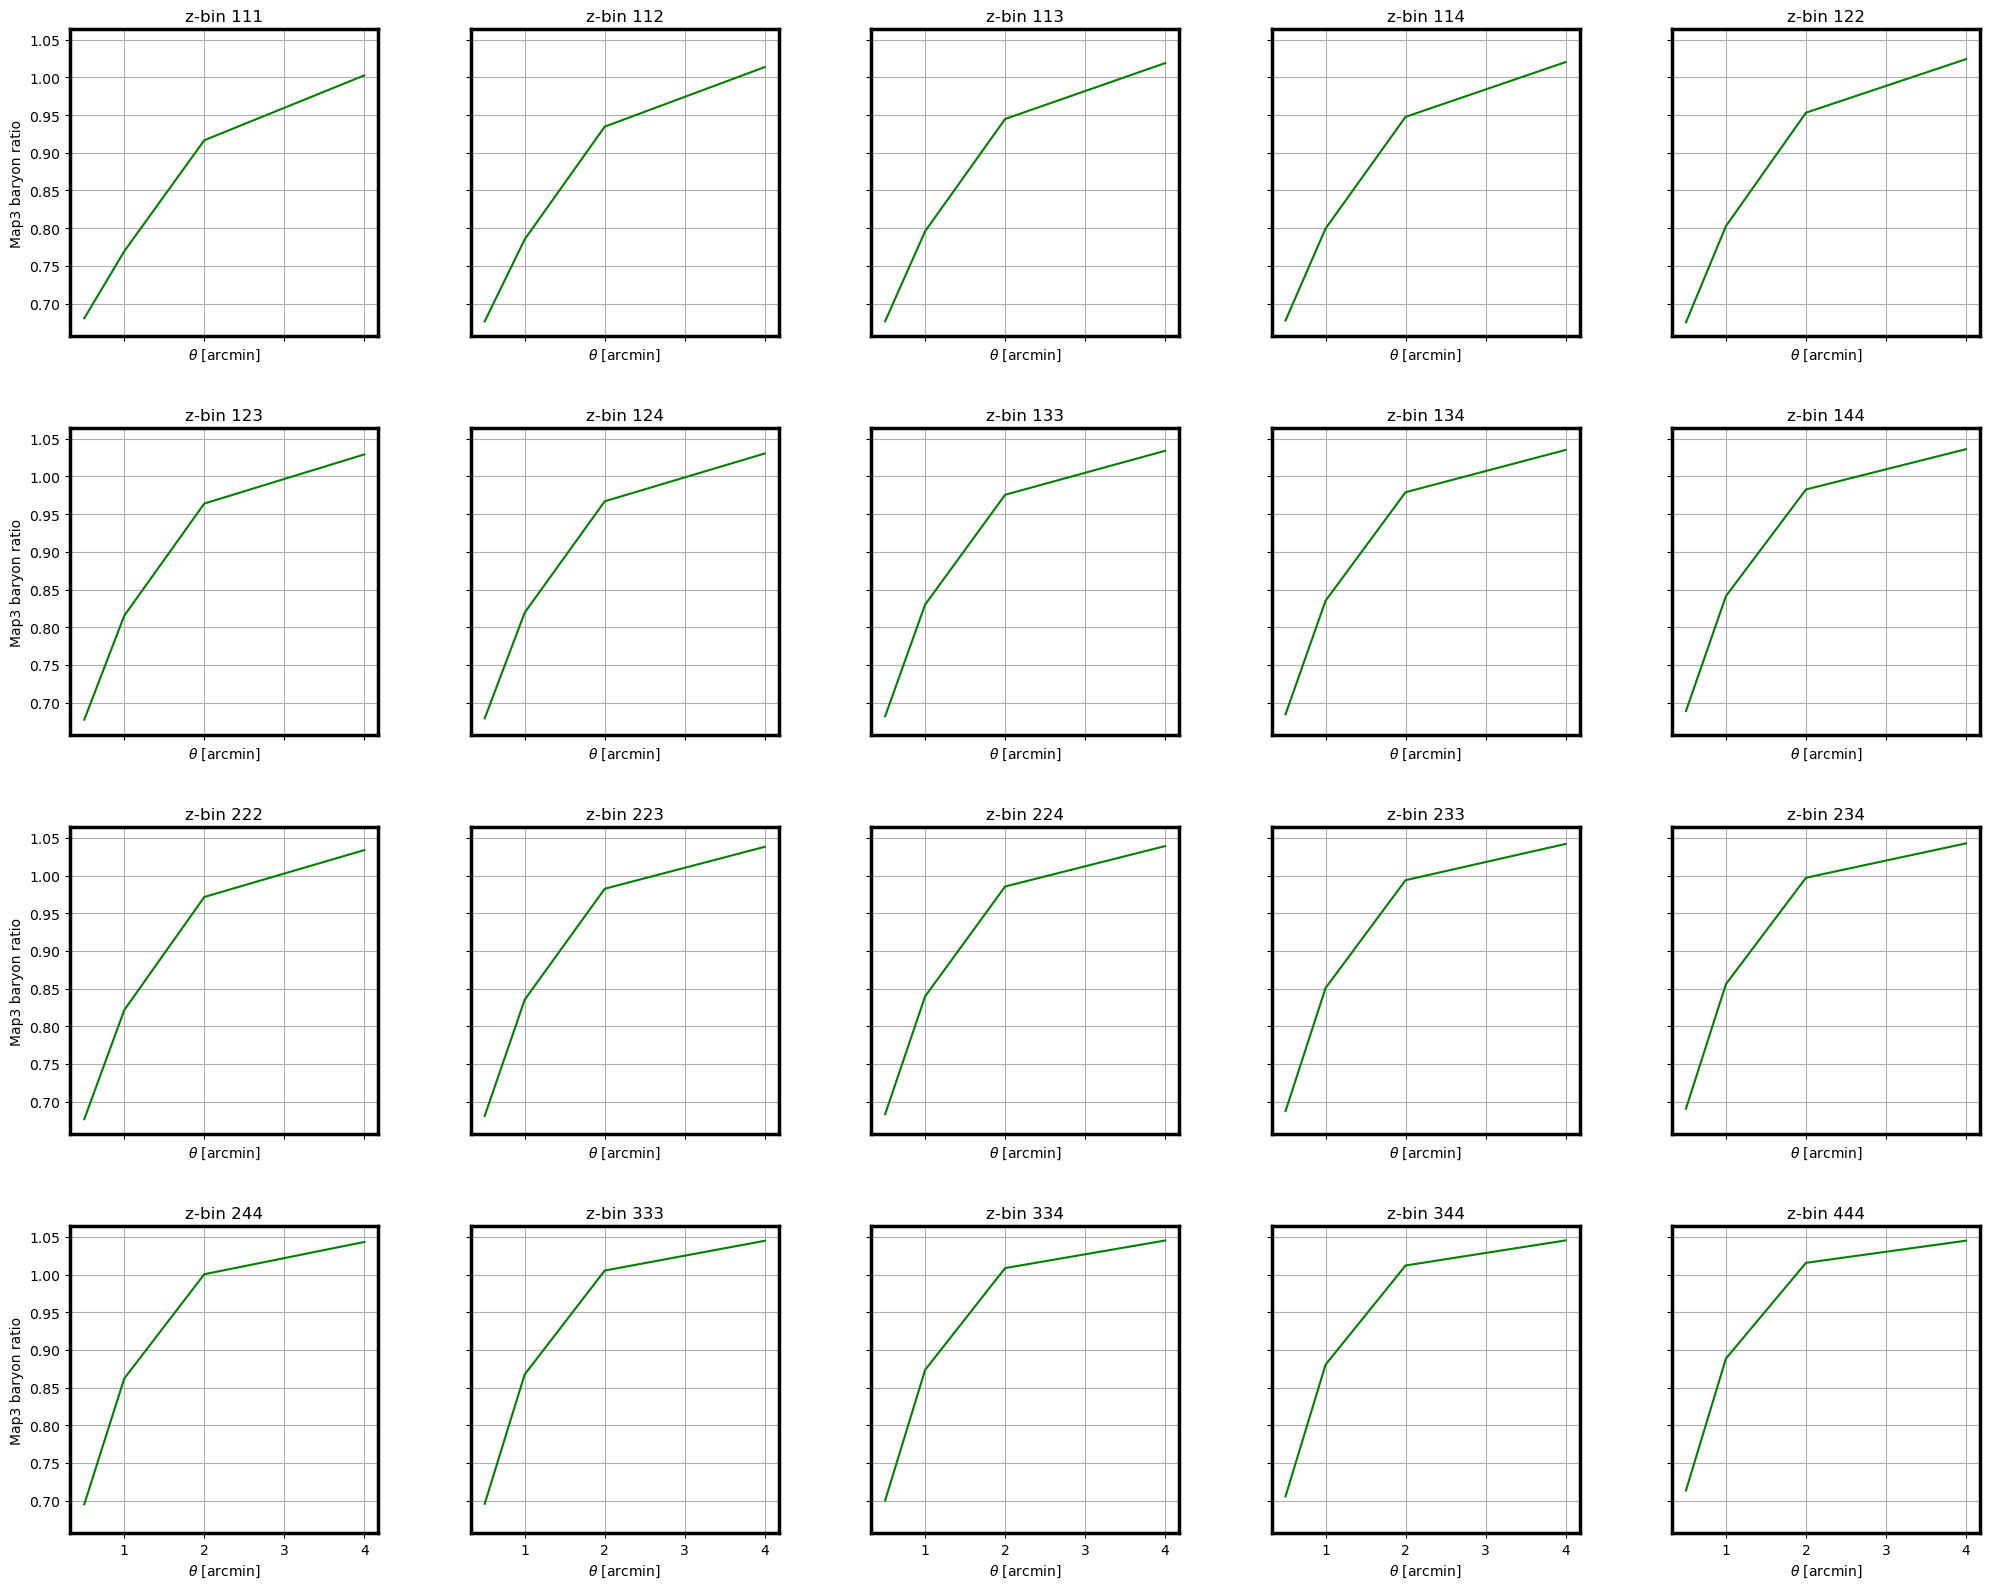

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
nob = fits.open('../data/dv/sim_map3-nobaryon-ultrasmallscales.fits')
owls = fits.open('../data/dv/sim_map3-OWLS-baryon-ultrasmallscales.fits')

#print(nob[1].data)
#print(owls[1].data)

ratio = np.zeros(80)
for i in range(80):
    ratio[i] = owls[1].data[i][6]/nob[1].data[i][6]
#    owls[1].data[i][6] = ratio[i]
print(ratio)

# Define x-axis values
x_values = np.array([0.5, 1, 2, 4])  # x-axis values in arcmins

# Define z-bin combinations
z_bin_combinations = [
    "111", "112", "113", "114", "122", "123", "124", 
    "133", "134", "144", "222", "223", "224", 
    "233", "234", "244", "333", "334", "344", "444"
]

# Split data vector into 20 sections (4 values each)
sections = [ratio[i * 4:(i + 1) * 4] for i in range(20)]

# Create subplots
fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharey=True, sharex=True)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each section
for i, ax in enumerate(axes):
    y_values = sections[i]
    ax.plot(x_values, y_values, linestyle='-', label=f'z-bin {z_bin_combinations[i]}', color='g')
    ax.set_title(f'z-bin {z_bin_combinations[i]}', fontsize=12)
    ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=10)
    if i % 5 == 0:  # Add y-label to the first column of plots
        ax.set_ylabel('Map3 baryon ratio', fontsize=10)
    ax.grid()

    # Thicker borders (spines)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

# Adjust layout for square plots and spacing
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)  # Adjust as needed for spacing
plt.show()
#plt.savefig("../plots/baryon_ratio_map3_jan2025_ultrasmallscales.pdf")

In [33]:
map3base = fits.open('../data/dv/sim_map3-NLA.fits')
for i in range(20):
    map3base[1].data[i*4][3] = 0.5
    map3base[1].data[i*4][4] = 0.5
    map3base[1].data[i*4][5] = 0.5
    map3base[1].data[i*4+1][3] = 1
    map3base[1].data[i*4+1][4] = 1
    map3base[1].data[i*4+1][5] = 1
    map3base[1].data[i*4+2][3] = 2
    map3base[1].data[i*4+2][4] = 2
    map3base[1].data[i*4+2][5] = 2
    map3base[1].data[i*4+3][3] = 4
    map3base[1].data[i*4+3][4] = 4
    map3base[1].data[i*4+3][5] = 4
#map3base.writeto("../data/dv/map3_ultrasmallscales.fits")

In [25]:
map3base = fits.open('../data/dv/map3_supersmallscales.fits')
print(map3base[1].data)

[(1, 1, 1,  3.,  3.,  3., 2.61622411e-10)
 (1, 1, 1,  6.,  6.,  6., 1.13274848e-10)
 (1, 1, 1, 12., 12., 12., 2.59703414e-11)
 (1, 1, 1, 24., 24., 24., 3.38098519e-12)
 (1, 1, 2,  3.,  3.,  3., 4.79337363e-10)
 (1, 1, 2,  6.,  6.,  6., 1.90407428e-10)
 (1, 1, 2, 12., 12., 12., 4.14345574e-11)
 (1, 1, 2, 24., 24., 24., 5.21501994e-12)
 (1, 1, 3,  3.,  3.,  3., 5.55584821e-10)
 (1, 1, 3,  6.,  6.,  6., 2.16331415e-10)
 (1, 1, 3, 12., 12., 12., 4.65513381e-11)
 (1, 1, 3, 24., 24., 24., 5.82000441e-12)
 (1, 1, 4,  3.,  3.,  3., 5.71590937e-10)
 (1, 1, 4,  6.,  6.,  6., 2.21361995e-10)
 (1, 1, 4, 12., 12., 12., 4.74911563e-11)
 (1, 1, 4, 24., 24., 24., 5.92706593e-12)
 (1, 2, 2,  3.,  3.,  3., 9.90066650e-10)
 (1, 2, 2,  6.,  6.,  6., 3.55381190e-10)
 (1, 2, 2, 12., 12., 12., 7.32269195e-11)
 (1, 2, 2, 24., 24., 24., 8.93915988e-12)
 (1, 2, 3,  3.,  3.,  3., 1.18722872e-09)
 (1, 2, 3,  6.,  6.,  6., 4.15895477e-10)
 (1, 2, 3, 12., 12., 12., 8.46933721e-11)
 (1, 2, 3, 24., 24., 24., 1.028209

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define x-axis values
x_values = np.array([7, 14, 25, 40])  # x-axis values in arcmins

# Define z-bin combinations
z_bin_combinations = [
    "111", "112", "113", "114", "122", "123", "124", 
    "133", "134", "144", "222", "223", "224", 
    "233", "234", "244", "333", "334", "344", "444"
]

# Split data vector into 20 sections (4 values each)
sections = [ratio[i * 4:(i + 1) * 4] for i in range(20)]

# Create subplots
fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharey=True, sharex=True)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each section
for i, ax in enumerate(axes):
    y_values = sections[i]
    ax.plot(x_values, y_values, linestyle='-', label=f'z-bin {z_bin_combinations[i]}', color='g')
    ax.set_title(f'z-bin {z_bin_combinations[i]}', fontsize=12)
    ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=10)
    if i % 5 == 0:  # Add y-label to the first column of plots
        ax.set_ylabel('Map3 baryon ratio', fontsize=10)
    ax.grid()

    # Thicker borders (spines)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

# Adjust layout for square plots and spacing
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)  # Adjust as needed for spacing
plt.show()
#plt.savefig("../plots/baryon_ratio_map3_jan2025.pdf")

NameError: name 'ratio' is not defined

In [80]:
import matplotlib.pyplot as plt

fitsmap3data_8 = fits.open('../data/dv/avg_map3-Cosmogrid-22Nov24-8arcmincut-WITH_COV.fits')
fitsmap3theo_8 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-22Nov24-nocut-oldfastnc.fits')

def my_array(fitsfile):
    
    map3 = np.zeros(80)
    for i in range(80):
        map3[i] = fitsfile[1].data[i][6]
        
    return(map3)

data_8cut = my_array(fitsmap3data_8)
theo_8cut = my_array(fitsmap3theo_8)

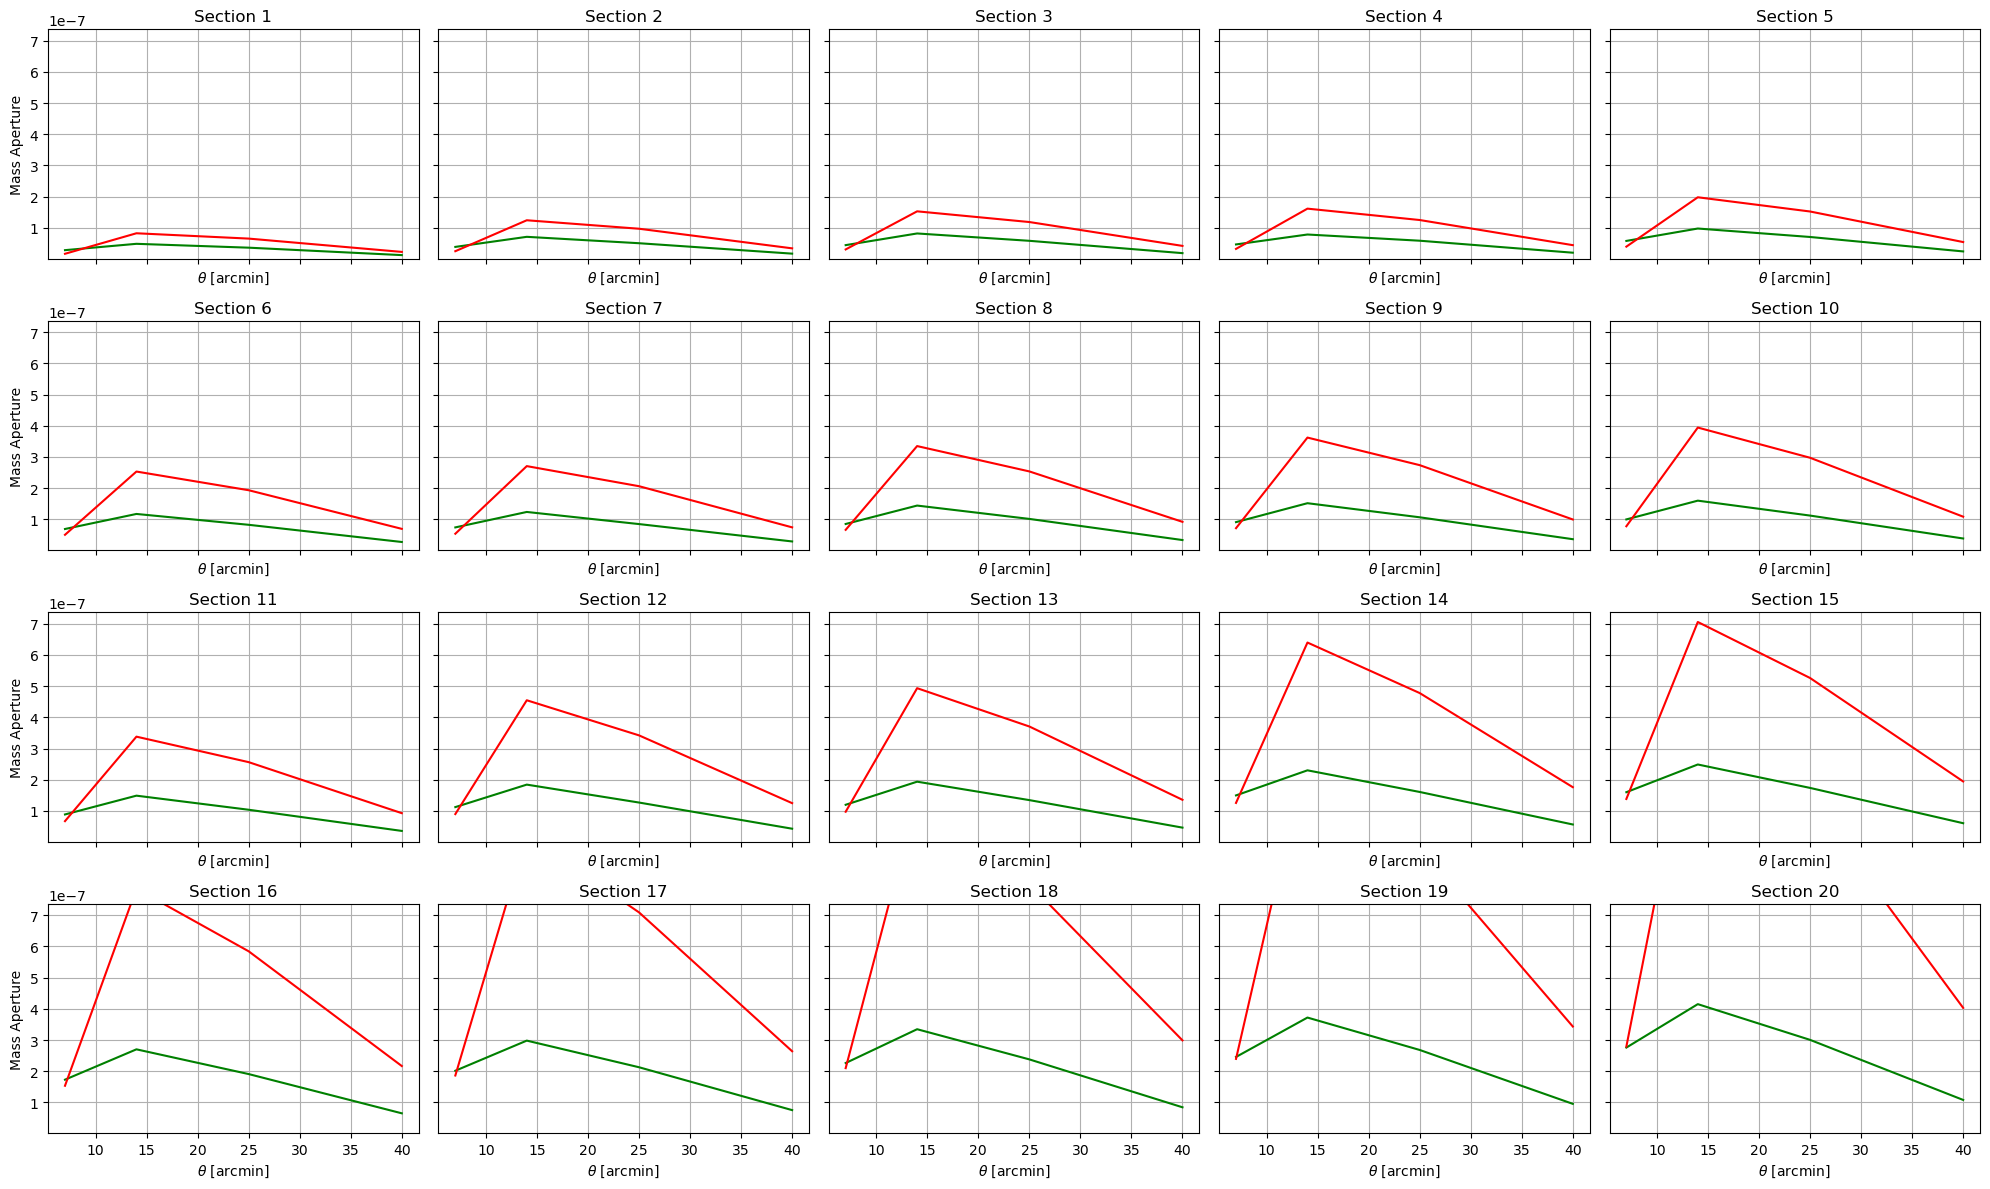

In [81]:
x_values = np.array([7, 14, 25, 40])  # x-axis values in arcmins

# Split data vector into 20 sections (4 values each)
sections = [data_8cut[i*4:(i+1)*4] for i in range(20)]
sections_theo = [theo_8cut[i*4:(i+1)*4] for i in range(20)]

# Create subplots
fig, axes = plt.subplots(4, 5, figsize=(20, 12), sharey=True, sharex=True)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each section
for i, ax in enumerate(axes):
    y_values = sections[i]
    y_theo = sections_theo[i]
    ax.plot(x_values, y_values*x_values**2, linestyle='-', label=f'Section {i+1}', color='g')
    ax.plot(x_values, y_theo*x_values**2, linestyle='-', label=f'Section {i+1}', color='r')
    ax.set_title(f'Section {i+1}')
    ax.set_xlabel(r'$\theta$ [arcmin]')
    if i % 5 == 0:  # Add y-label to the first column of plots
        ax.set_ylabel('Mass Aperture')
    ax.grid()

# Ensure the y-axis scale is the same across plots
y_min = min(theo_8cut*49)
y_max = max(theo_8cut*100)
for ax in axes:
    ax.set_ylim(y_min, y_max)

# Adjust layout
plt.tight_layout()
plt.show()

In [48]:
print(np.logspace(np.log10(0.5), np.log10(80), 21))

[ 0.5         0.64443038  0.83058102  1.07050328  1.37972966  1.77827941
  2.29195454  2.95401025  3.80730788  4.9070897   6.32455532  8.15147113
 10.50611122 13.54091441 17.45235314 22.49365301 28.99118655 37.36560252
 48.15905858 62.0703205  80.        ]


In [6]:
from astropy.io import fits
twopt1_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim1-BESTFIT.fits')
twopt2_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim2-BESTFIT.fits')
twopt3_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim3-BESTFIT.fits')
twopt_all_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sims_all-BESTFIT.fits')
twopt_all_2ptbf = fits.open('../data/dv/sim_2pt-NLA-some-sims-2pt-sims_all-BESTFIT.fits')

In [7]:
twopt1_data = fits.open('../data/dv/meas_2pt-sim1-cosmogrid.fits')
twopt2_data = fits.open('../data/dv/meas_2pt-sim2-cosmogrid.fits')
twopt3_data = fits.open('../data/dv/meas_2pt-sim3-cosmogrid.fits')
twopt_all_data = fits.open('../data/dv/meas_2pt-ave-cosmogrid_weighted.fits')

In [8]:
def extract_2pt(fitsfile):
    
    xip = fitsfile[2].data
    xim = fitsfile[3].data
    
    out = np.zeros(400)
    for i in range(200):
        out[i] = fitsfile[2].data[i][3]
        out[i+200] = fitsfile[3].data[i][3]
        
    return(out)

In [9]:
def transform_data(datav):
    transf_moped = np.loadtxt('../data/moped/moped-moped-compress-2pt.txt')
    transformed_data = np.dot(transf_moped.T, datav)
    return(transformed_data)

def transform_cov(covm):
    transf_moped = np.loadtxt('../data/moped/moped-moped-compress-2pt.txt')
    newtransf = np.zeros(shape=(307,96))
    print(np.shape(newtransf[:227,:][:,:16]))
    newtransf[:227,:][:,:16] = transf_moped
    newtransf[227:,:][:,16:] = np.eye(80)
    transformed_cov = np.dot(newtransf.T, np.dot(covm, newtransf))
    return(transformed_cov)

In [10]:
scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])

In [11]:
scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))

In [12]:
scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))

In [13]:
def scale_cut_2pt(vector):
    scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])
    scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))
    scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))
    return (np.delete(vector, scale_cuts_all))

In [14]:
def scale_cut_2pt_cov(matrix):
    scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])
    scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))
    scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))
    matrix = np.delete(matrix, scale_cuts_all, axis=0)
    matrix = np.delete(matrix, scale_cuts_all, axis=1)
    return (matrix)

In [15]:
from astropy.io import fits
to_cov = fits.open("../data/covariance/cov_xip_xim_map3.fits")
cov_all_nocut = to_cov[1].data
cov_all = transform_cov(scale_cut_2pt_cov(cov_all_nocut))

(227, 16)


In [16]:
twpt1 = transform_data(scale_cut_2pt(extract_2pt(twopt1_data)))
twpt2 = transform_data(scale_cut_2pt(extract_2pt(twopt2_data)))
twpt3 = transform_data(scale_cut_2pt(extract_2pt(twopt3_data)))
twpt_all = transform_data(scale_cut_2pt(extract_2pt(twopt_all_data)))

twpt_bf_sim1 = transform_data(scale_cut_2pt(extract_2pt(twopt1_file)))
twpt_bf_sim2 = transform_data(scale_cut_2pt(extract_2pt(twopt2_file)))
twpt_bf_sim3 = transform_data(scale_cut_2pt(extract_2pt(twopt3_file)))
twpt_bf_all = transform_data(scale_cut_2pt(extract_2pt(twopt_all_file)))

twpt_bf_only = transform_data(scale_cut_2pt(extract_2pt(twopt_all_2ptbf)))

In [17]:
dados1 = np.concatenate((twpt1,thpt1.get_signal()))
dados2 = np.concatenate((twpt2,thpt2.get_signal()))
dados3 = np.concatenate((twpt3,thpt3.get_signal()))
dados_all = np.concatenate((twpt_all,thpt_all.get_signal()))

teoria1 = np.concatenate((twpt_bf_sim1,thpt_bf_sim1.get_signal()))
teoria2 = np.concatenate((twpt_bf_sim2,thpt_bf_sim2.get_signal()))
teoria3 = np.concatenate((twpt_bf_sim3,thpt_bf_sim3.get_signal()))
teoria_all = np.concatenate((twpt_bf_all,thpt_bf_all.get_signal()))

In [101]:
minus_file = fits.open('../data/dv/sim_map3-NLA-cosmoCosmoG-mnutest0.fits')
minus_file.info()
dataminus = minus_file[1].data
print(dataminus)
for i in range(len(dataminus)):
    dataminus[i][6] = -1*dataminus[i][6]

plus_file = minus_file
plus_file[1].data = dataminus
#output_path = '../data/dv/altered_sign_sim_map3-NLA-cosmoCosmoG-mnutest0-emulated.fits'
#plus_file.writeto(output_path, overwrite=False)

Filename: ../data/dv/sim_map3-NLA-cosmoCosmoG-mnutest0-emulated.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
[(1, 1, 1,  7.,  7.,  7., 6.37989928e-10)
 (1, 1, 1, 14., 14., 14., 2.46574142e-10)
 (1, 1, 1, 25., 25., 25., 5.33034676e-11)
 (1, 1, 1, 40., 40., 40., 6.71352382e-12)
 (1, 1, 2,  7.,  7.,  7., 9.24596056e-10)
 (1, 1, 2, 14., 14., 14., 3.38506926e-10)
 (1, 1, 2, 25., 25., 25., 7.14063877e-11)
 (1, 1, 2, 40., 40., 40., 8.89855339e-12)
 (1, 1, 3,  7.,  7.,  7., 1.11099596e-09)
 (1, 1, 3, 14., 14., 14., 3.95830243e-10)
 (1, 1, 3, 25., 25., 25., 8.26335392e-11)
 (1, 1, 3, 40., 40., 40., 1.02631094e-11)
 (1, 1, 4,  7.,  7.,  7., 1.16531878e-09)
 (1, 1, 4, 14., 14., 14., 4.12298928e-10)
 (1, 1, 4, 25., 25., 25., 8.58644012e-11)
 (1, 1, 4, 40., 40., 40., 1.06575294e-11)
 (1,

In [107]:
plus_file = fits.open('../data/dv/sim_map3-NLA-cosmoCosmoG-mnutest0-emulated.fits')
plus_file.info()
dataplus = plus_file[1].data
print(dataplus)

Filename: ../data/dv/sim_map3-NLA-cosmoCosmoG-mnutest0-emulated.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
[(1, 1, 1,  7.,  7.,  7., 6.37989928e-10)
 (1, 1, 1, 14., 14., 14., 2.46574142e-10)
 (1, 1, 1, 25., 25., 25., 5.33034676e-11)
 (1, 1, 1, 40., 40., 40., 6.71352382e-12)
 (1, 1, 2,  7.,  7.,  7., 9.24596056e-10)
 (1, 1, 2, 14., 14., 14., 3.38506926e-10)
 (1, 1, 2, 25., 25., 25., 7.14063877e-11)
 (1, 1, 2, 40., 40., 40., 8.89855339e-12)
 (1, 1, 3,  7.,  7.,  7., 1.11099596e-09)
 (1, 1, 3, 14., 14., 14., 3.95830243e-10)
 (1, 1, 3, 25., 25., 25., 8.26335392e-11)
 (1, 1, 3, 40., 40., 40., 1.02631094e-11)
 (1, 1, 4,  7.,  7.,  7., 1.16531878e-09)
 (1, 1, 4, 14., 14., 14., 4.12298928e-10)
 (1, 1, 4, 25., 25., 25., 8.58644012e-11)
 (1, 1, 4, 40., 40., 40., 1.06575294e-11)
 (1,

In [85]:
theory_mnu009 = threepoint.ThreePointDataClass.from_fits('../data/dv/altered_sign_sim_map3-NLA-cosmoCosmoG-mnutest0.fits')
thmnu_009 = -1*theory_mnu009.get_signal()
thmnu_006 = thpt_theo.get_signal()
datamap3 = thpt_all.get_signal()

In [86]:
diff_mnu006 = datamap3 - thmnu_006
diff_mnu009 = datamap3 - thmnu_009

numm = (500-diff_mnu006.size-2)/(500-1)
invcovar = np.linalg.inv(cov_all[16:,:][:,16:]) * numm
chi2mnu006 = diff_mnu006.dot(invcovar).dot(diff_mnu006)
dofmnu006  = diff_mnu006.size
print('{:.3f}/{}={:.3f}'.format(chi2mnu006, dofmnu006, chi2mnu006/dofmnu006))
chi2mnu009 = diff_mnu009.dot(invcovar).dot(diff_mnu009)
dofmnu009  = diff_mnu009.size
print('{:.3f}/{}={:.3f}'.format(chi2mnu009, dofmnu009, chi2mnu009/dofmnu009))

0.710/80=0.009
655.439/80=8.193


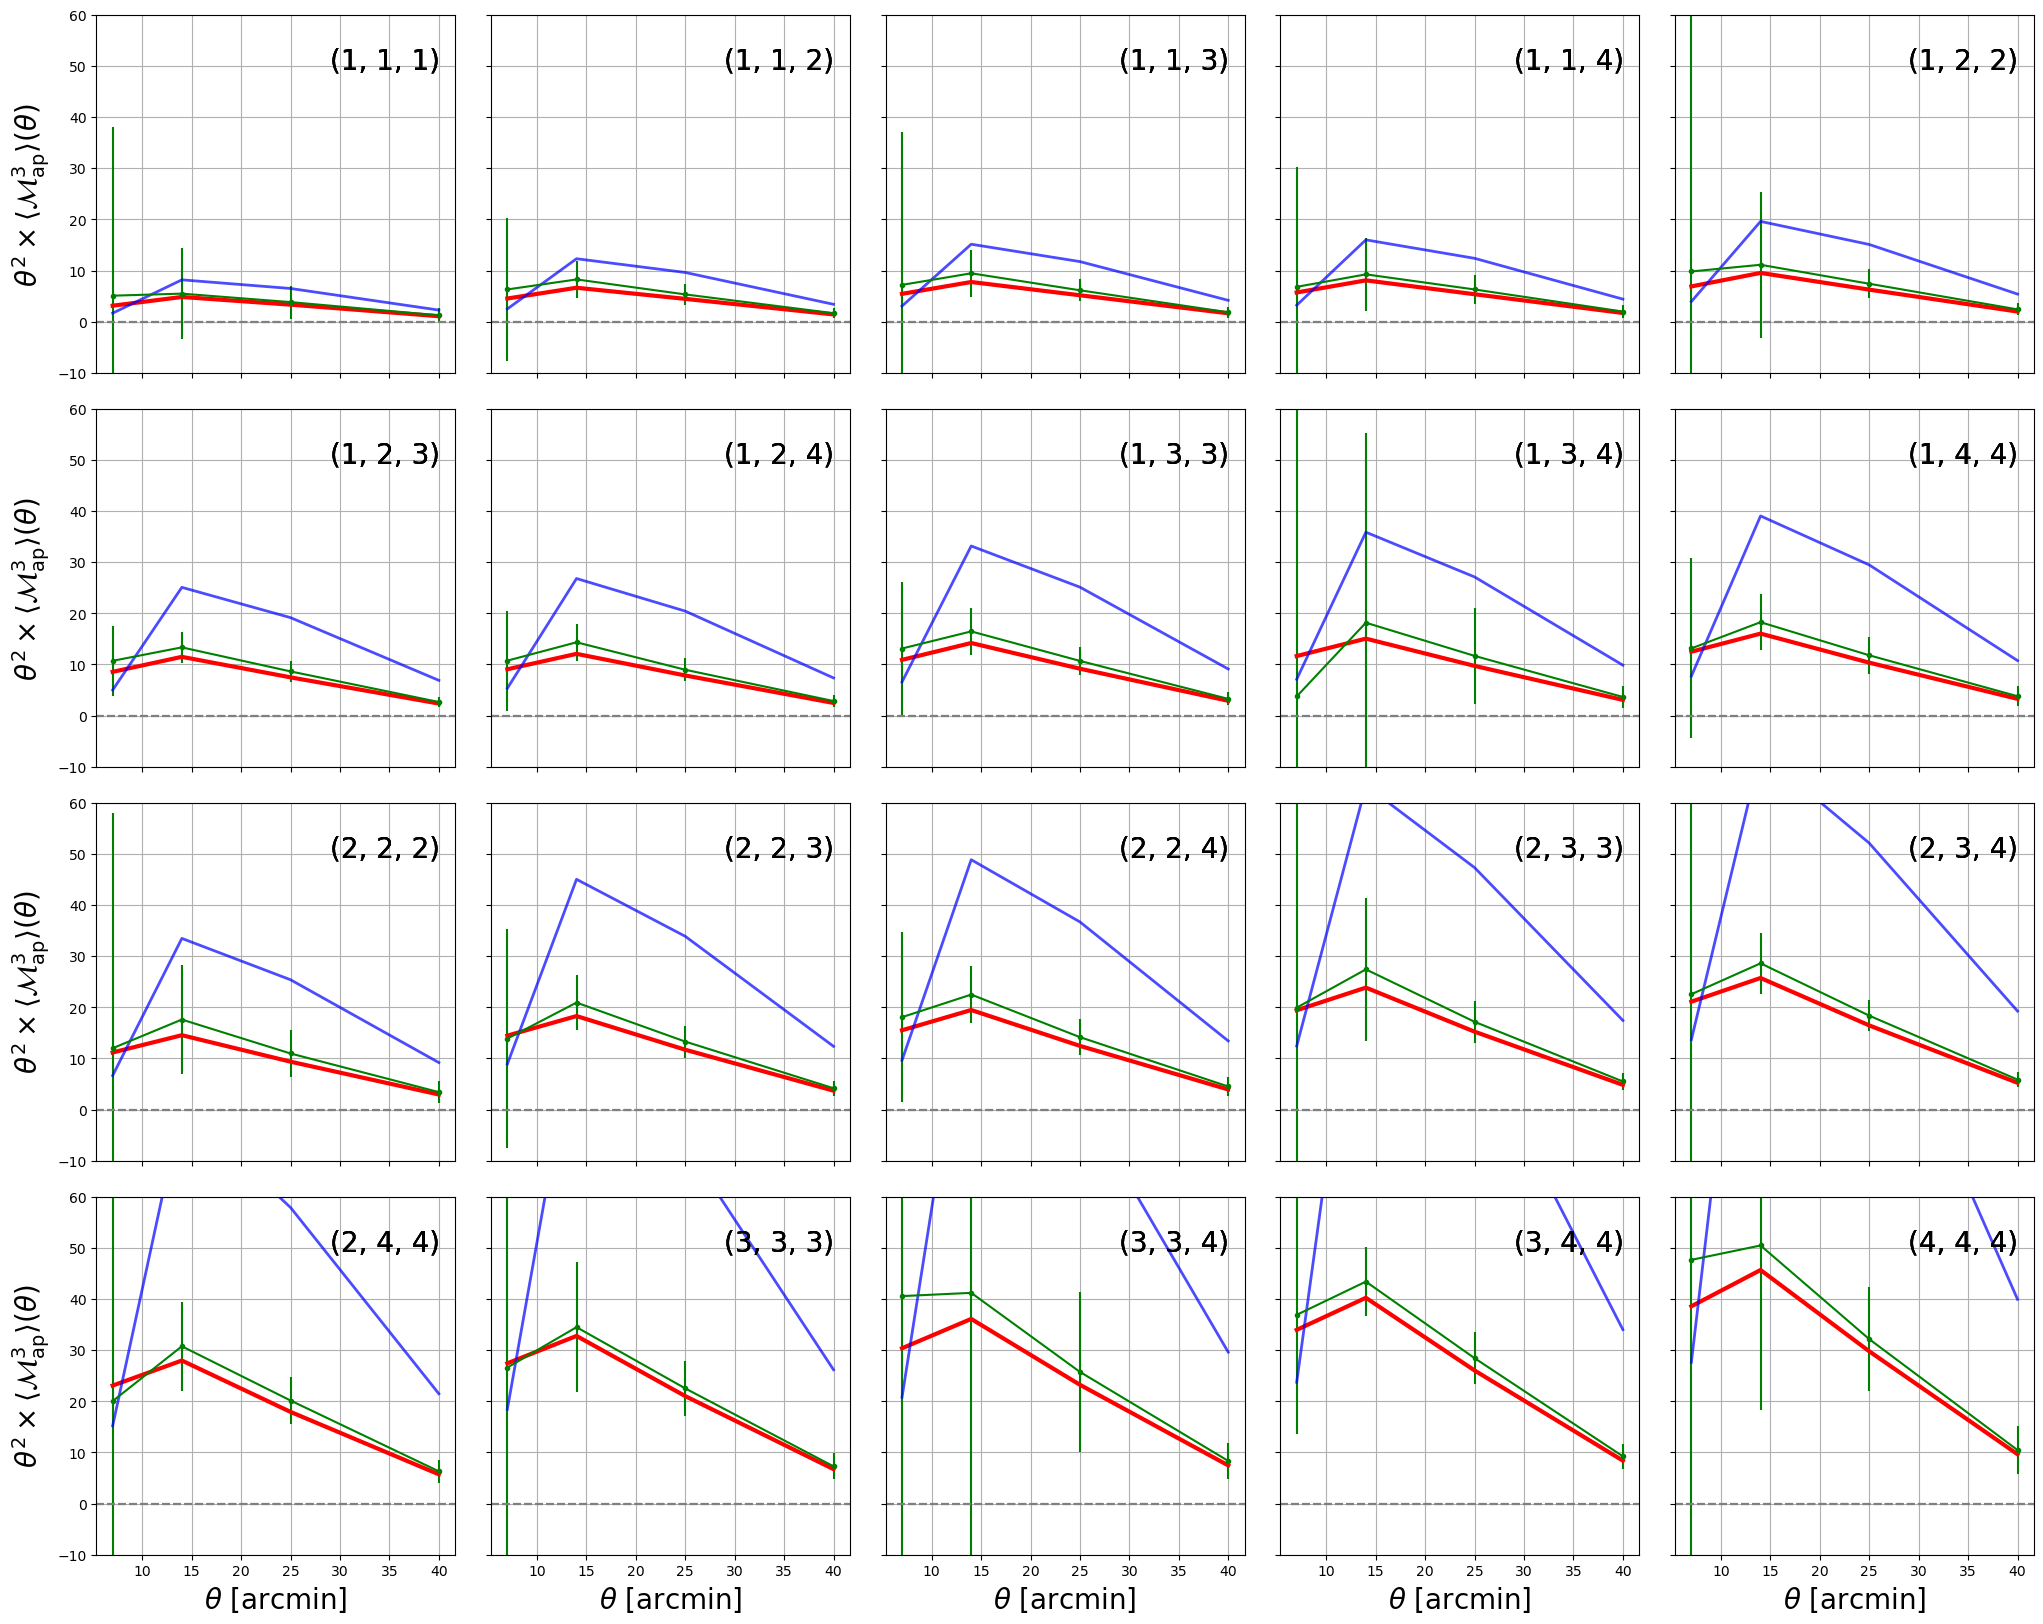

In [87]:
line_args = dict(color='g', ls='-')
fig, axes = thpt_all.plot2d(4, 5, figsize=(25, 20), **line_args)
line_args2 = dict(color='r', lw=3, ls='-')
fig, axes = thpt_theo.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args2)
line_args3 = dict(color='b', alpha=0.7, lw=2, ls='-')
fig, axes = theory_mnu009.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args3)
for ax in axes.flatten():
    ax.grid(True)
    ax.set_ylim(-10,60)
plt.show()

In [64]:
dife1 = dados1 - teoria1
dife2 = dados2 - teoria2
dife3 = dados3 - teoria3
dife_all = dados_all - teoria_all

f = (500-dife1.size-2)/(500-1)
icov_all = np.linalg.inv(cov_all) * f

chi21 = dife1.dot(icov_all).dot(dife1)
dof1  = dife1.size
print('{:.3f}/{}={:.3f}'.format(chi21, dof1, chi21/dof1))

chi22 = dife2.dot(icov_all).dot(dife2)
dof2  = dife2.size
print('{:.3f}/{}={:.3f}'.format(chi22, dof2, chi22/dof2))

chi23 = dife3.dot(icov_all).dot(dife3)
dof3  = dife3.size
print('{:.3f}/{}={:.3f}'.format(chi23, dof3, chi23/dof3))

chi2_all = dife_all.dot(icov_all).dot(dife_all)
dof_all  = dife_all.size
print('{:.3f}/{}={:.3f}'.format(chi2_all, dof_all, chi2_all/dof_all))

79.110/96=0.824
71.417/96=0.744
79.207/96=0.825
2.013/96=0.021


In [65]:
dadosm = thpt_all.get_signal()
teoriam = thpt_bf_map3_all.get_signal()

difem = dadosm - teoriam
cov_allm = to_cov[1].data[400:,:][:,400:]

f = (500-difem.size-2)/(500-1)
icov_allm = np.linalg.inv(cov_allm) * f

chi2m = difem.dot(icov_allm).dot(difem)
dofm  = difem.size
print('{:.3f}/{}={:.3f}'.format(chi2m, dofm, chi2m/dofm))

0.419/80=0.005


In [66]:
dadosx = twpt_all
teoriax = twpt_bf_only

difex = dadosx - teoriax
cov_allx = cov_all[:16,:][:,:16]

f = (500-difex.size-2)/(500-1)
icov_allx = np.linalg.inv(cov_allx) * f

chi2x = difex.dot(icov_allx).dot(difex)
dofx  = difex.size
print('{:.3f}/{}={:.3f}'.format(chi2x, dofx, chi2x/dofx))

1.013/16=0.063
